# Hotel Booking Cancellation Risk Assessment
### A Predictive Analytics Report for Revenue Management

---

## The Business Problem

This project builds a machine learning system that predicts which hotel bookings are likely to cancel, and how severe that risk is. The output is a prioritised watch-list the revenue team can act on before a cancellation happens.

The problem is straightforward: when a booking cancels without warning, the room sits empty and the revenue is gone. The goal is to give the team enough advance notice to intervene, whether that means a retention offer, a room reassignment, or simply knowing to keep a closer eye on a particular reservation.

Two models power the system:

- **Cancellation Classifier (Logistic Regression):** Predicts whether a booking will cancel. Binary output, one score per booking.
- **Severity Scorer (XGBoost Multiclass):** Goes further and places every booking into one of four risk tiers (0 to 3) based on cancellation probability. This tells the team not just whether to act, but how urgently.

The rest of this report walks through the full process, from raw data to trained models.

| Section | Topic |
|---------|-------|
| 1 | The Dataset |
| 2 | Exploratory Data Analysis |
| 3 | Data Cleaning |
| 4 | Outlier Capping |
| 5 | Feature Engineering and Correlation |
| 6 | Final Dataset Verification |
| 7 | Univariate Outlier Analysis |
| 8 | Multivariate Outlier Analysis |
| 9 | Cancellation Prediction Model |
| 10 | Overfitting Check |
| 11 | Class Imbalance Assessment |
| 12 | Severity Scoring |
| 13 | Severity Classification Model |
| 14 | Results and Recommendations |


In [127]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from scipy import stats
from scipy.stats import chi2
from sklearn.model_selection import train_test_split, learning_curve, cross_val_predict
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve,
    f1_score, precision_score, recall_score,
    average_precision_score, precision_recall_curve,
)
from xgboost import XGBClassifier


## 1. The Dataset

This analysis uses a publicly available hotel bookings dataset with 119,390 reservations across two property types: a city hotel and a resort hotel. Each row is a booking with 32 attributes captured at or before the time of booking, including lead time, distribution channel, room type, guest count, special requests, deposit type, and cancellation history.

The target variable is `is_canceled`: 1 if the booking cancelled, 0 if it completed. Everything in this project is built around predicting that field.

We start with a quick look at the raw data before changing anything.


In [128]:
hotel_bookings = pd.read_csv('hotel_bookings.csv')
hotel_bookings.tail(25)


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
119365,City Hotel,0,54,2017,August,35,27,3,5,1,...,No Deposit,14.0,NaN,0,Transient,266.75,0,1,Check-Out,2017-09-04
119366,City Hotel,0,210,2017,August,35,28,2,5,2,...,No Deposit,7.0,NaN,0,Transient,85.59,0,1,Check-Out,2017-09-04
119367,City Hotel,0,212,2017,August,35,28,2,5,2,...,No Deposit,7.0,NaN,0,Transient,85.59,0,0,Check-Out,2017-09-04
119368,City Hotel,0,261,2017,August,35,30,1,4,2,...,No Deposit,14.0,NaN,0,Transient,99.00,0,0,Check-Out,2017-09-04
119369,City Hotel,0,207,2017,August,34,25,3,7,2,...,No Deposit,14.0,NaN,0,Transient,96.25,0,2,Check-Out,2017-09-04
119370,City Hotel,0,201,2017,August,35,30,1,4,1,...,No Deposit,9.0,NaN,0,Transient,108.00,0,2,Check-Out,2017-09-04
119371,City Hotel,0,175,2017,August,35,31,1,3,2,...,No Deposit,42.0,NaN,0,Transient,86.85,0,2,Check-Out,2017-09-04
119372,City Hotel,0,175,2017,August,35,31,1,3,1,...,No Deposit,42.0,NaN,0,Transient,82.35,0,1,Check-Out,2017-09-04
119373,City Hotel,0,175,2017,August,35,31,1,3,1,...,No Deposit,42.0,NaN,0,Transient,82.35,0,1,Check-Out,2017-09-04
119374,City Hotel,0,201,2017,August,35,29,1,5,2,...,No Deposit,9.0,NaN,0,Transient,117.00,0,2,Check-Out,2017-09-04


## 2. Exploratory Data Analysis

Before any modelling, we need to understand what we are working with. This section covers five questions:

1. **How many bookings cancelled?** Baseline cancellation rate.
2. **How are numerical features distributed?** Skew, range, and outliers at a glance.
3. **Which customer segments cancel more?** Channel, market segment, deposit type, customer type.
4. **Is there a seasonal pattern?** Monthly and hotel-type breakdowns.
5. **Where is data missing?** Fields with gaps and how significant they are.

Nothing gets built until we have a clear view of the data.


In [129]:
hotel_bookings.describe()

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
count,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119386.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,103050.000000,6797.000000,119390.000000,119390.000000,119390.000000,119390.000000
mean,0.370416,104.011416,2016.156554,27.165173,15.798241,0.927599,2.500302,1.856403,0.103890,0.007949,0.031912,0.087118,0.137097,0.221124,86.693382,189.266735,2.321149,101.831122,0.062518,0.571363
std,0.482918,106.863097,0.707476,13.605138,8.780829,0.998613,1.908286,0.579261,0.398561,0.097436,0.175767,0.844336,1.497437,0.652306,110.774548,131.655015,17.594721,50.535790,0.245291,0.792798
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,6.000000,0.000000,-6.380000,0.000000,0.000000
25%,0.000000,18.000000,2016.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,62.000000,0.000000,69.290000,0.000000,0.000000
50%,0.000000,69.000000,2016.000000,28.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.000000,179.000000,0.000000,94.575000,0.000000,0.000000
75%,1.000000,160.000000,2017.000000,38.000000,23.000000,2.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,229.000000,270.000000,0.000000,126.000000,0.000000,1.000000
max,1.000000,737.000000,2017.000000,53.000000,31.000000,19.000000,50.000000,55.000000,10.000000,10.000000,1.000000,26.000000,72.000000,21.000000,535.000000,543.000000,391.000000,5400.000000,8.000000,5.000000


In [130]:
hotel_bookings.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

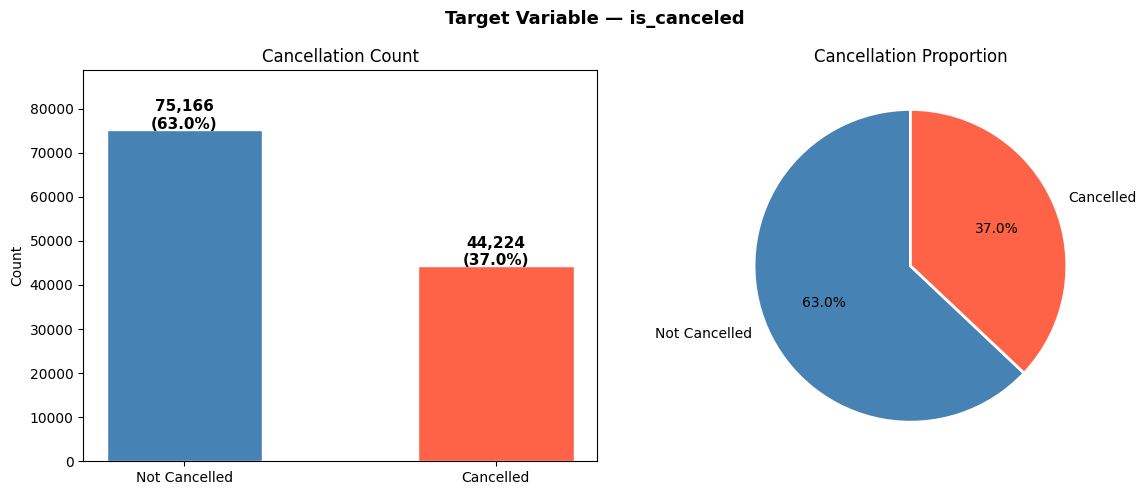

In [131]:
cancel_count = hotel_bookings['is_canceled'].value_counts().sort_index()
labels = ['Not Cancelled', 'Cancelled']
colors = ['steelblue', 'tomato']

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

bars = axes[0].bar(labels, cancel_count.values, color=colors, edgecolor='white', width=0.5)
for bar, val in zip(bars, cancel_count.values):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 300,
                 f'{val:,}\n({val / len(hotel_bookings) * 100:.1f}%)',
                 ha='center', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Count')
axes[0].set_title('Cancellation Count')
axes[0].set_ylim(0, cancel_count.max() * 1.18)

axes[1].pie(cancel_count.values, labels=labels, colors=colors,
            autopct='%1.1f%%', startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Cancellation Proportion')

plt.suptitle('Target Variable — is_canceled', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [132]:
categorical_cols = hotel_bookings.select_dtypes(include=['object', 'category']).columns
numerical_cols = hotel_bookings.select_dtypes(include=['number']).columns

categorical_cols, numerical_cols

(Index(['hotel', 'arrival_date_month', 'meal', 'country', 'market_segment',
        'distribution_channel', 'reserved_room_type', 'assigned_room_type',
        'deposit_type', 'customer_type', 'reservation_status',
        'reservation_status_date'],
       dtype='object'),
 Index(['is_canceled', 'lead_time', 'arrival_date_year',
        'arrival_date_week_number', 'arrival_date_day_of_month',
        'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children',
        'babies', 'is_repeated_guest', 'previous_cancellations',
        'previous_bookings_not_canceled', 'booking_changes', 'agent', 'company',
        'days_in_waiting_list', 'adr', 'required_car_parking_spaces',
        'total_of_special_requests'],
       dtype='object'))

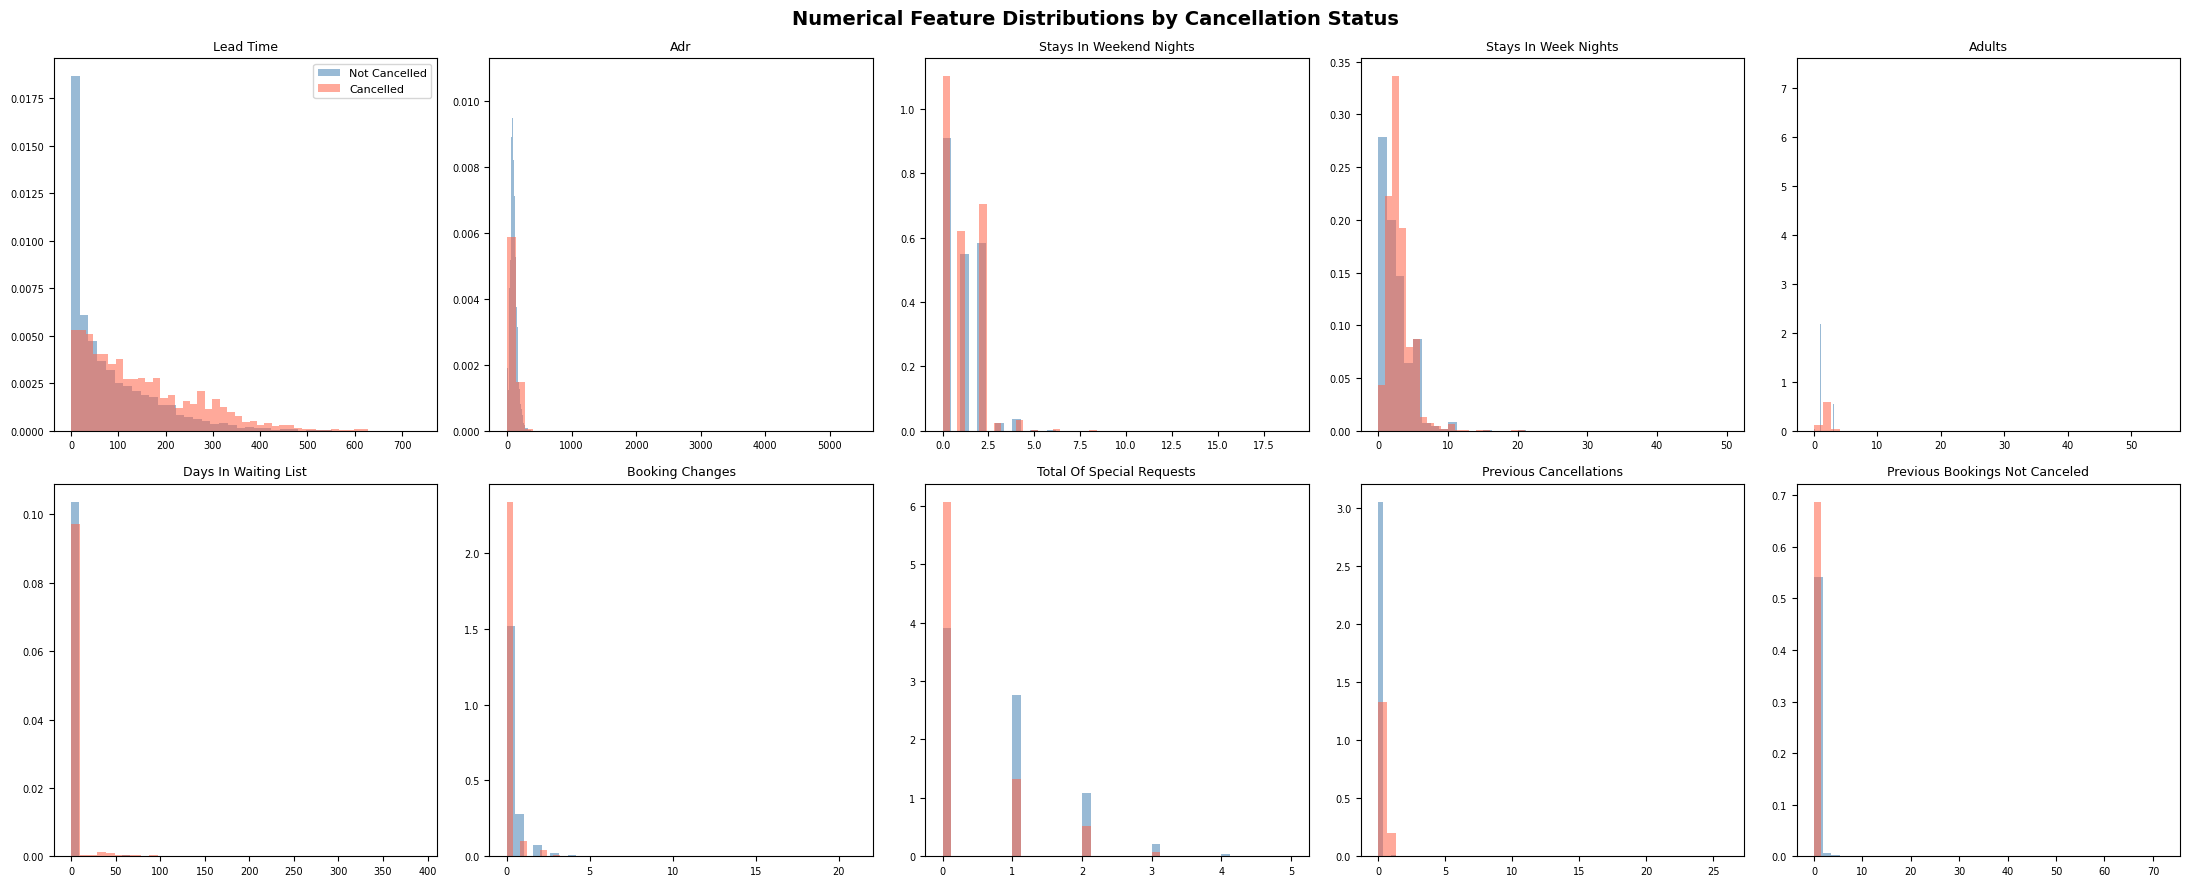

In [133]:
num_cols_viz = [
    'lead_time', 'adr', 'stays_in_weekend_nights', 'stays_in_week_nights',
    'adults', 'days_in_waiting_list', 'booking_changes', 'total_of_special_requests',
    'previous_cancellations', 'previous_bookings_not_canceled'
]
fig, axes = plt.subplots(2, 5, figsize=(22, 9))
axes = axes.flatten()

for i, col in enumerate(num_cols_viz):
    for val, color, lbl in [(0, 'steelblue', 'Not Cancelled'), (1, 'tomato', 'Cancelled')]:
        data = hotel_bookings[hotel_bookings['is_canceled'] == val][col].dropna()
        axes[i].hist(data, bins=40, alpha=0.55, color=color, label=lbl, density=True)
    axes[i].set_title(col.replace('_', ' ').title(), fontsize=9)
    axes[i].tick_params(labelsize=7)
    if i == 0:
        axes[i].legend(fontsize=8)

plt.suptitle('Numerical Feature Distributions by Cancellation Status', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

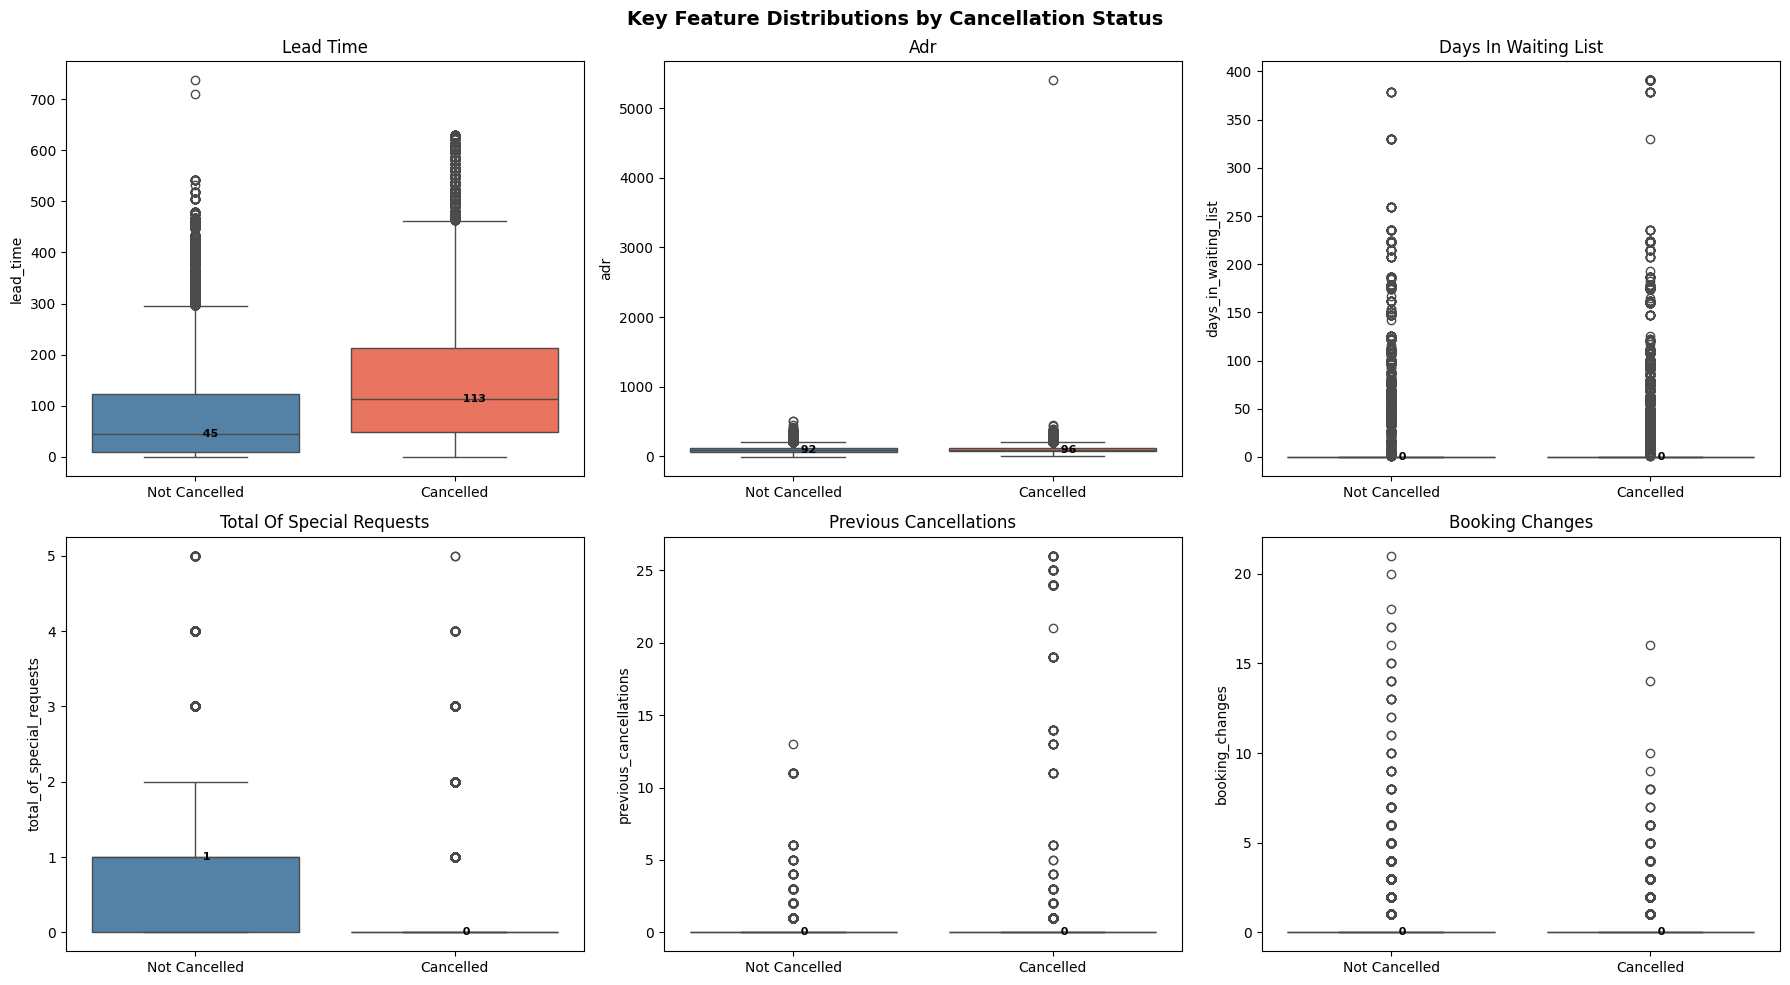

In [134]:
key_features = ['lead_time', 'adr', 'days_in_waiting_list',
                'total_of_special_requests', 'previous_cancellations', 'booking_changes']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(key_features):
    sns.boxplot(data=hotel_bookings, x='is_canceled', y=col,
                hue='is_canceled',
                palette={0: 'steelblue', 1: 'tomato'},
                dodge=False, legend=False, ax=axes[i])
    axes[i].set_xticks([0, 1])
    axes[i].set_xticklabels(['Not Cancelled', 'Cancelled'])
    axes[i].set_title(col.replace('_', ' ').title())
    axes[i].set_xlabel('')
    for j, cls in enumerate([0, 1]):
        med = hotel_bookings[hotel_bookings['is_canceled'] == cls][col].median()
        axes[i].text(j, med, f'  {med:.0f}', va='center', fontsize=8, fontweight='bold')

plt.suptitle('Key Feature Distributions by Cancellation Status', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


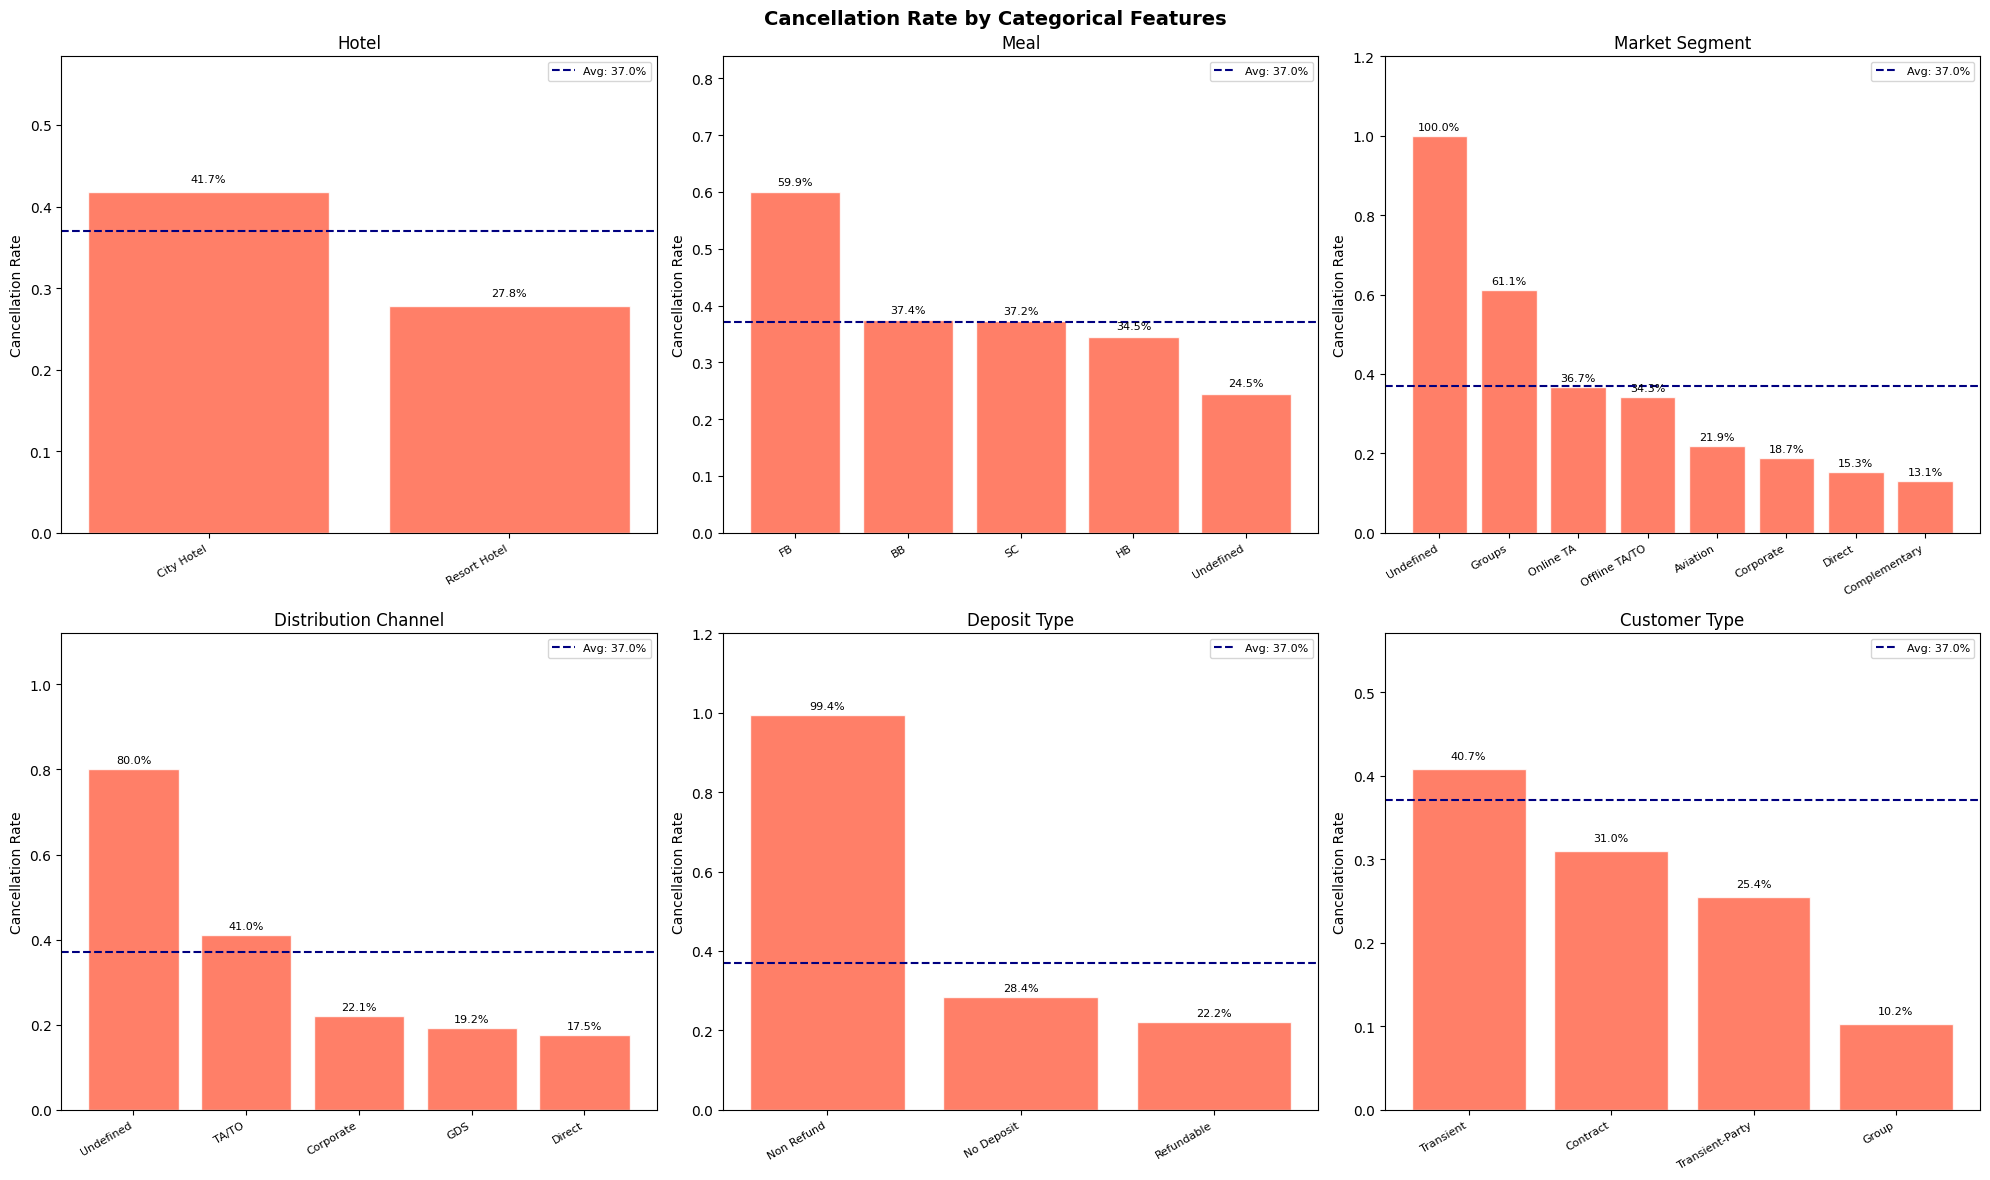

In [135]:
cat_cols_viz = ['hotel', 'meal', 'market_segment',
                'distribution_channel', 'deposit_type', 'customer_type']
overall_rate = hotel_bookings['is_canceled'].mean()

fig, axes = plt.subplots(2, 3, figsize=(20, 12))
axes = axes.flatten()

for i, col in enumerate(cat_cols_viz):
    rate = hotel_bookings.groupby(col)['is_canceled'].mean().sort_values(ascending=False)
    bars = axes[i].bar(range(len(rate)), rate.values,
                       color='tomato', alpha=0.82, edgecolor='white')
    axes[i].set_xticks(range(len(rate)))
    axes[i].set_xticklabels(rate.index, rotation=30, ha='right', fontsize=8)
    for bar, val in zip(bars, rate.values):
        axes[i].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
                     f'{val:.1%}', ha='center', va='bottom', fontsize=8)
    axes[i].axhline(overall_rate, color='navy', linestyle='--', lw=1.5,
                    label=f'Avg: {overall_rate:.1%}')
    axes[i].set_ylim(0, min(1.2, rate.max() * 1.4))
    axes[i].set_ylabel('Cancellation Rate')
    axes[i].set_title(col.replace('_', ' ').title())
    axes[i].legend(fontsize=8)

plt.suptitle('Cancellation Rate by Categorical Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

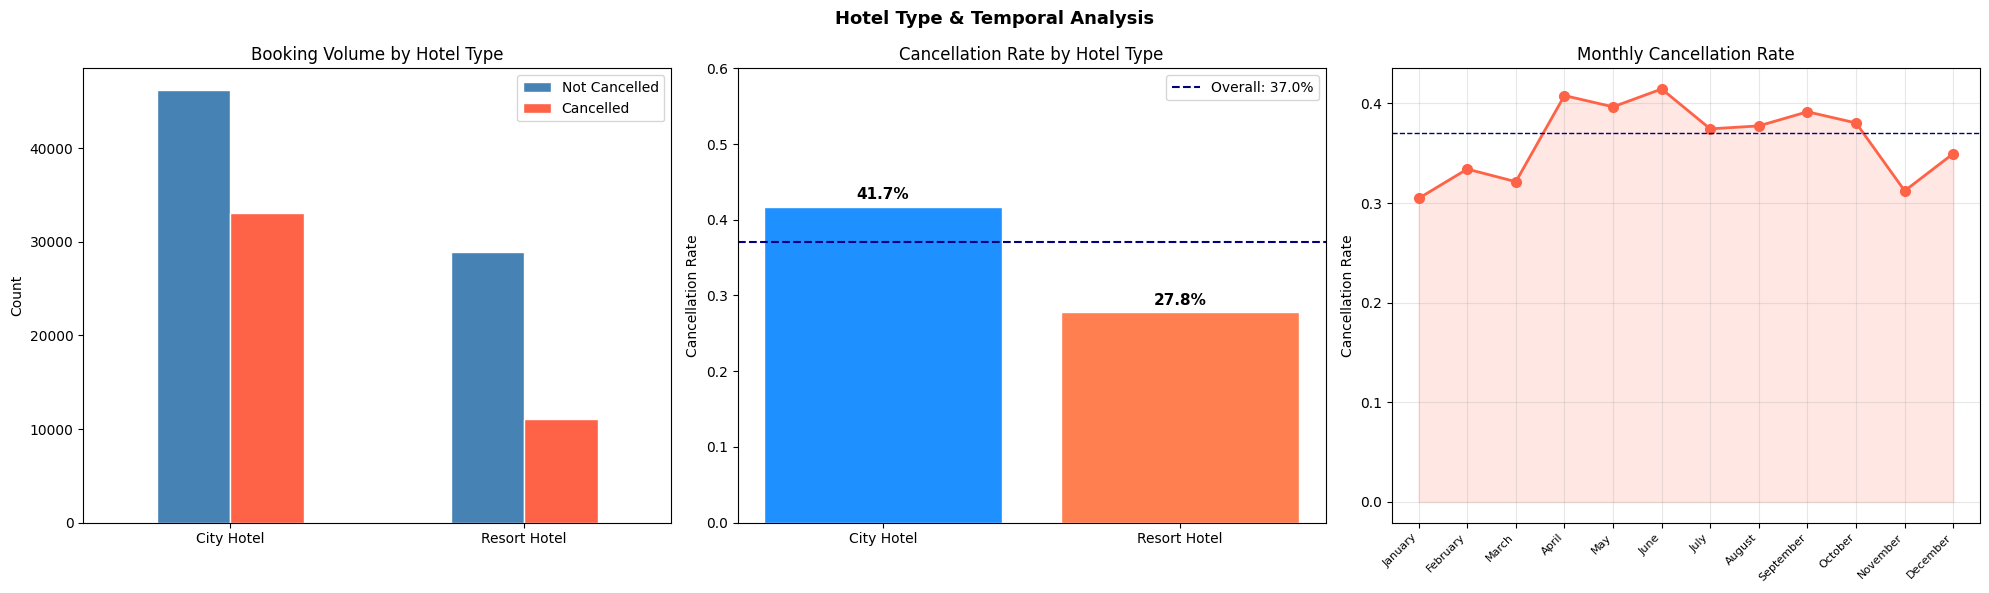

In [136]:
month_order = ['January', 'February', 'March', 'April', 'May', 'June',
               'July', 'August', 'September', 'October', 'November', 'December']

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

hotel_df = hotel_bookings.groupby(['hotel', 'is_canceled']).size().unstack(fill_value=0)
hotel_df.columns = ['Not Cancelled', 'Cancelled']
hotel_df.plot(kind='bar', ax=axes[0], color=['steelblue', 'tomato'], edgecolor='white')
axes[0].set_title('Booking Volume by Hotel Type')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=0)
axes[0].set_ylabel('Count')
axes[0].legend()

hotel_rate = hotel_bookings.groupby('hotel')['is_canceled'].mean()
axes[1].bar(hotel_rate.index, hotel_rate.values,
            color=['dodgerblue', 'coral'], edgecolor='white')
for i, (idx, val) in enumerate(hotel_rate.items()):
    axes[1].text(i, val + 0.01, f'{val:.1%}', ha='center', fontsize=11, fontweight='bold')
axes[1].axhline(hotel_bookings['is_canceled'].mean(), color='navy', linestyle='--', lw=1.5,
               label=f'Overall: {hotel_bookings["is_canceled"].mean():.1%}')
axes[1].set_ylim(0, 0.6)
axes[1].set_title('Cancellation Rate by Hotel Type')
axes[1].set_ylabel('Cancellation Rate')
axes[1].legend()

monthly = hotel_bookings.groupby('arrival_date_month')['is_canceled'].mean()
monthly = monthly.reindex([m for m in month_order if m in monthly.index])
x = list(range(len(monthly)))
axes[2].plot(x, monthly.values, 'o-', color='tomato', lw=2, ms=7)
axes[2].fill_between(x, monthly.values, alpha=0.15, color='tomato')
axes[2].set_xticks(x)
axes[2].set_xticklabels(monthly.index, rotation=45, ha='right', fontsize=8)
axes[2].set_ylabel('Cancellation Rate')
axes[2].set_title('Monthly Cancellation Rate')
axes[2].grid(True, alpha=0.3)
axes[2].axhline(hotel_bookings['is_canceled'].mean(), color='navy', linestyle='--', lw=1)

plt.suptitle('Hotel Type & Temporal Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

company     112593
agent        16340
country        488
children         4


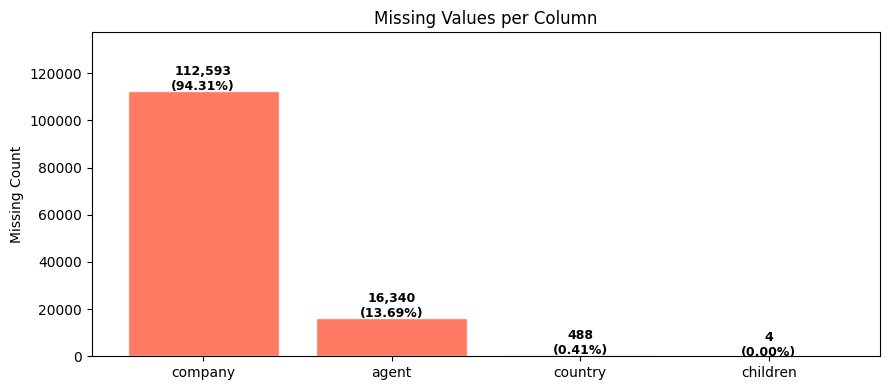

In [137]:
missing = hotel_bookings.isnull().sum()
missing_nonzero = missing[missing > 0].sort_values(ascending=False)
print(missing_nonzero.to_string())

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(missing_nonzero.index, missing_nonzero.values,
              color='tomato', edgecolor='white', alpha=0.85)
for bar, val in zip(bars, missing_nonzero.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 300,
            f'{val:,}\n({val / len(hotel_bookings) * 100:.2f}%)',
            ha='center', fontsize=9, fontweight='bold')
ax.set_ylabel('Missing Count')
ax.set_title('Missing Values per Column')
ax.set_ylim(0, missing_nonzero.max() * 1.22)
plt.tight_layout()
plt.show()

## 3. Data Cleaning

The raw dataset has predictable imperfections: empty fields, placeholder values, and columns that encode the future, which we cannot use for prediction.

| Issue | Fields Affected | Resolution | Rationale |
|-------|----------------|------------|-----------|
| Missing values | `children` (4 rows) | Fill with 0 | Absence of children is the default |
| Missing values | `country` (488 rows) | Fill with 'Unknown' | Country is sometimes unavailable at booking time |
| Missing values | `agent` (16,340 rows) | Fill with 'no_agent' | Direct booking with no agent |
| Missing values | `company` (112,593 rows) | Fill with 'no_company' | Not a corporate booking |
| Nonsense values | `adr = 0` with positive stay | Remove | A zero nightly rate is not a valid booking |
| Data leakage | `reservation_status`, `reservation_status_date` | Drop entirely | These columns encode the outcome we are trying to predict |

The last point is critical. `reservation_status` directly records whether the booking was cancelled. Any model trained with it would look near-perfect but be useless in production, since that field only exists after the fact.


In [138]:
hotel_bookings['country'] = hotel_bookings['country'].replace(np.nan, 'Unknown')
hotel_bookings['agent']   = hotel_bookings['agent'].replace(np.nan, 'no_agent')
hotel_bookings['company'] = hotel_bookings['company'].replace(np.nan, 'no_company')
hotel_bookings['children'] = hotel_bookings['children'].replace(np.nan, 0)

hb = hotel_bookings.copy()

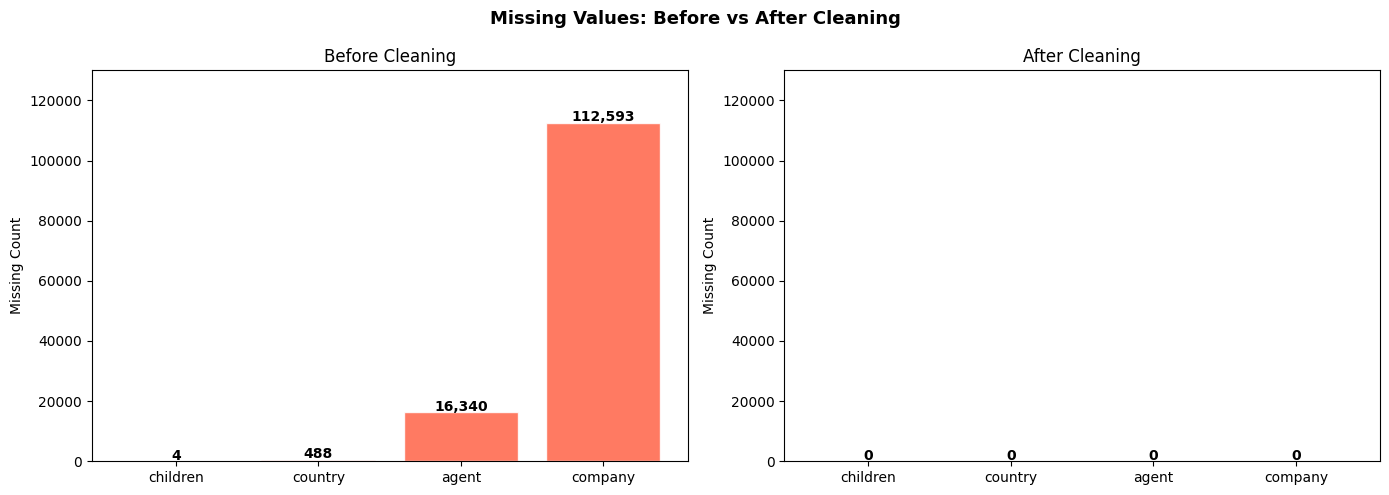

In [139]:
before_nulls = {'children': 4, 'country': 488, 'agent': 16340, 'company': 112593}
after_nulls  = {col: int(hb[col].isnull().sum()) for col in before_nulls}
cols_null = list(before_nulls.keys())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, (data, title, color) in zip(axes, [
        (before_nulls, 'Before Cleaning', 'tomato'),
        (after_nulls,  'After Cleaning',  'seagreen')]):
    bars = ax.bar(cols_null, [data[c] for c in cols_null],
                  color=color, edgecolor='white', alpha=0.85)
    for bar, col in zip(bars, cols_null):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 500,
                f'{data[col]:,}', ha='center', fontsize=10, fontweight='bold')
    ax.set_ylabel('Missing Count')
    ax.set_title(title)
    ax.set_ylim(0, 130000)

plt.suptitle('Missing Values: Before vs After Cleaning', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 4. Outlier Management: Capping Extreme Values

Some bookings have extreme values: lead times over 500 days, nightly rates above £5,000, waiting lists in the hundreds. These may be genuine cases, but they can distort what the model learns about typical booking patterns.

Rather than dropping these rows, we apply Tukey fencing. For each numerical column, values beyond 1.5 times the interquartile range are clipped to the boundary. The booking stays in the dataset, but its extreme value is brought back in line.

The before-and-after plots confirm the correction is working.


In [140]:
Q1 = hb[['lead_time', 'adr']].quantile(0.25)
Q3 = hb[['lead_time', 'adr']].quantile(0.75)
IQR = Q3 - Q1

lower_fence = Q1 - 1.5 * IQR
upper_fence = Q3 + 1.5 * IQR

print(f"Tukey fences:\n{pd.DataFrame({'Lower': lower_fence, 'Upper': upper_fence}).to_string()}\n")

for col in ['lead_time', 'adr']:
    n = ((hb[col] < lower_fence[col]) | (hb[col] > upper_fence[col])).sum()
    print(f"  {col}: {n} outliers ({n / len(hb) * 100:.2f}%)")

# Cap (Winsorise) at fence boundaries — preserves row count
hb_capped = hb.copy()
for col in ['lead_time', 'adr']:
    hb_capped[col] = hb_capped[col].clip(lower=lower_fence[col], upper=upper_fence[col])

Tukey fences:
             Lower    Upper
lead_time -195.000  373.000
adr        -15.775  211.065

  lead_time: 3005 outliers (2.52%)
  adr: 3793 outliers (3.18%)


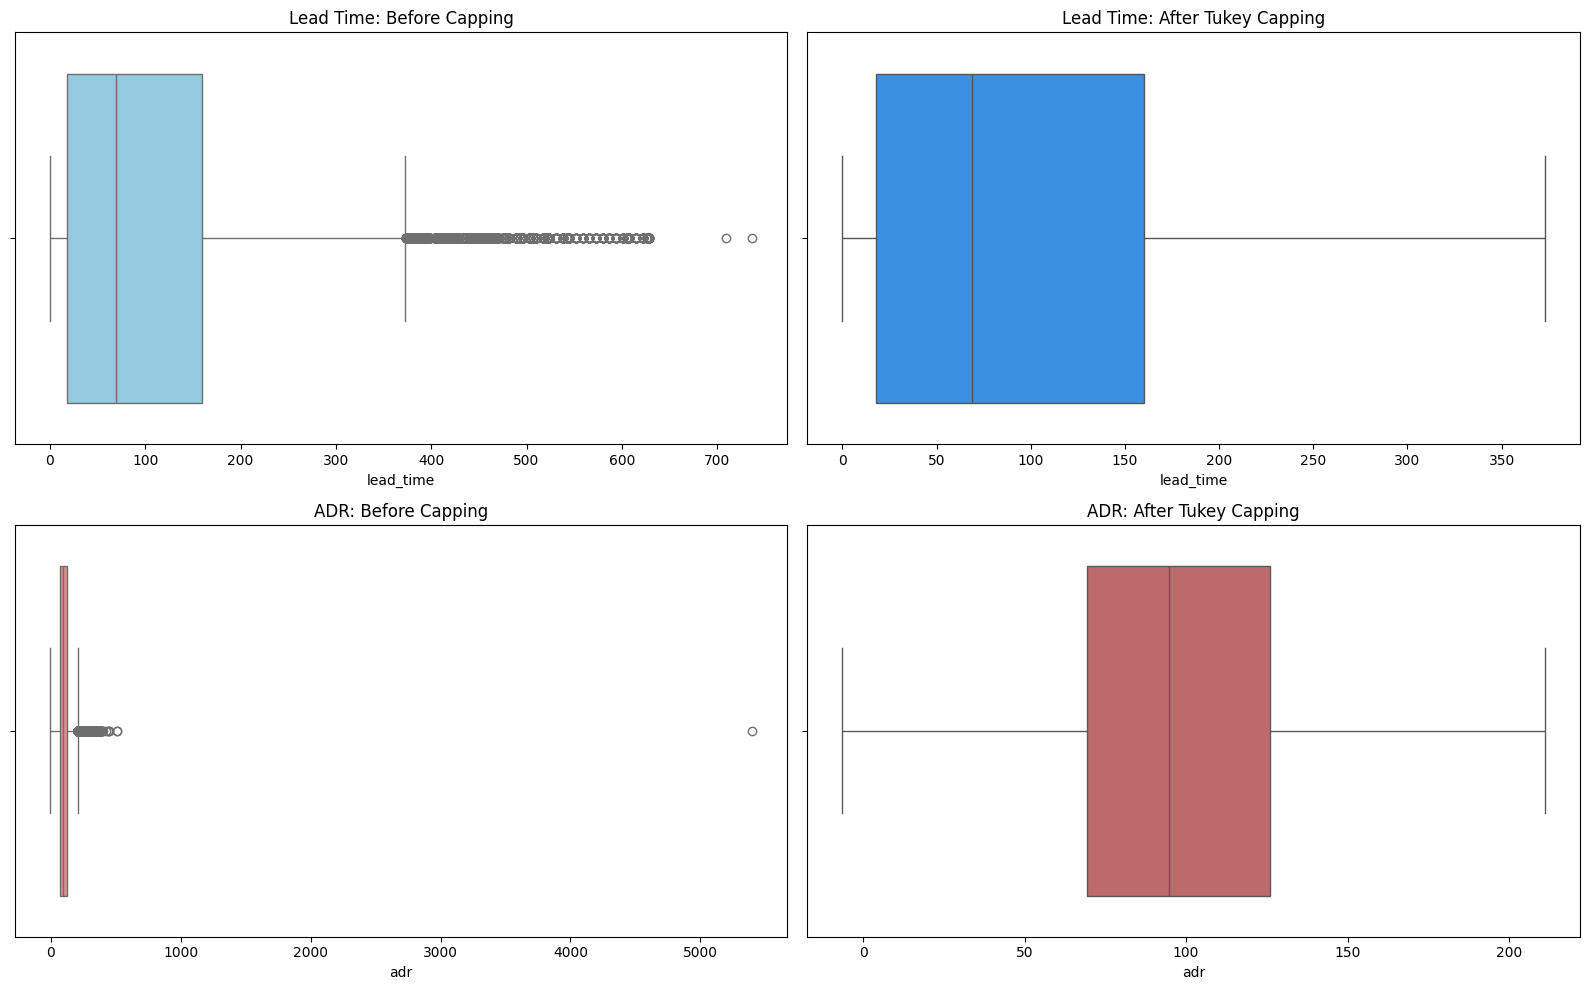

In [141]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# LEAD TIME
sns.boxplot(data=hb, x='lead_time', ax=axes[0, 0], color='skyblue')
axes[0, 0].set_title('Lead Time: Before Capping')

sns.boxplot(data=hb_capped, x='lead_time', ax=axes[0, 1], color='dodgerblue')
axes[0, 1].set_title('Lead Time: After Tukey Capping')

# ADR (Average Daily Rate)
sns.boxplot(data=hb, x='adr', ax=axes[1, 0], color='lightcoral')
axes[1, 0].set_title('ADR: Before Capping')

sns.boxplot(data=hb_capped, x='adr', ax=axes[1, 1], color='indianred')
axes[1, 1].set_title('ADR: After Tukey Capping')

plt.tight_layout()
plt.show()


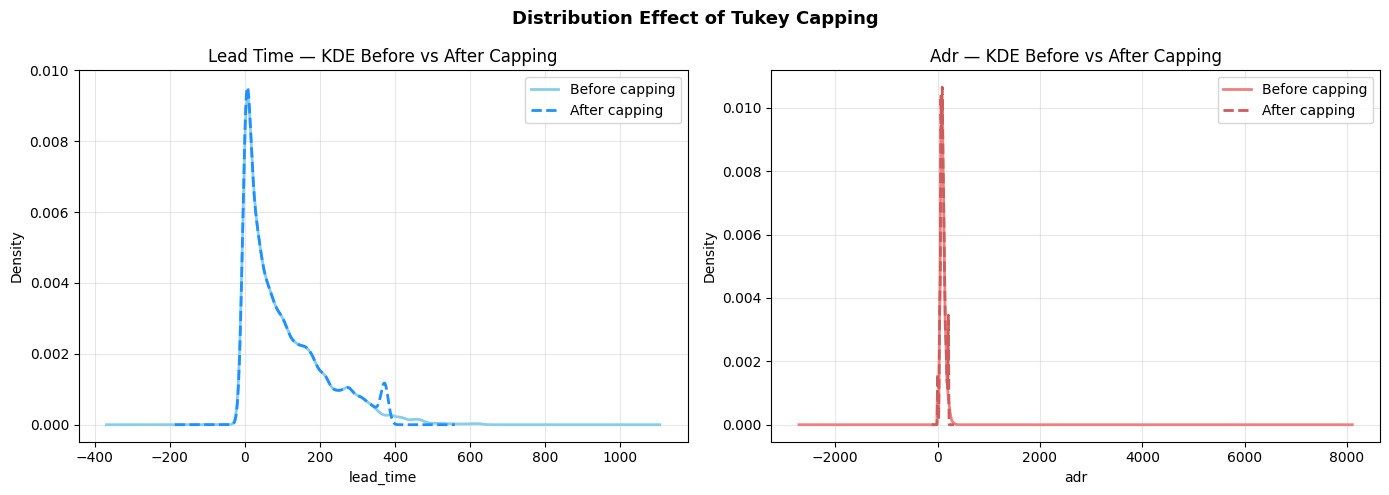

In [142]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, col, c_before, c_after in [
        (axes[0], 'lead_time', 'skyblue',    'dodgerblue'),
        (axes[1], 'adr',       'lightcoral', 'indianred')]:
    hb[col].plot.kde(ax=ax, color=c_before, lw=2, label='Before capping')
    hb_capped[col].plot.kde(ax=ax, color=c_after, lw=2, linestyle='--', label='After capping')
    ax.set_title(f'{col.replace("_", " ").title()} — KDE Before vs After Capping')
    ax.set_xlabel(col)
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle('Distribution Effect of Tukey Capping', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [143]:
hb_capped = hb_capped.drop(columns=['reservation_status', 'reservation_status_date'])
hb_capped

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,C,3,No Deposit,no_agent,no_company,0,Transient,0.000,0,0
1,Resort Hotel,0,373,2015,July,27,1,0,0,2,...,C,4,No Deposit,no_agent,no_company,0,Transient,0.000,0,0
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,C,0,No Deposit,no_agent,no_company,0,Transient,75.000,0,0
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,A,0,No Deposit,304.0,no_company,0,Transient,75.000,0,0
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,A,0,No Deposit,240.0,no_company,0,Transient,98.000,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119385,City Hotel,0,23,2017,August,35,30,2,5,2,...,A,0,No Deposit,394.0,no_company,0,Transient,96.140,0,0
119386,City Hotel,0,102,2017,August,35,31,2,5,3,...,E,0,No Deposit,9.0,no_company,0,Transient,211.065,0,2
119387,City Hotel,0,34,2017,August,35,31,2,5,2,...,D,0,No Deposit,9.0,no_company,0,Transient,157.710,0,4
119388,City Hotel,0,109,2017,August,35,31,2,5,2,...,A,0,No Deposit,89.0,no_company,0,Transient,104.400,0,0


## 5. Feature Engineering and Correlation Analysis

Machine learning models need numbers. Categorical fields like `market_segment`, `hotel`, and `deposit_type` need converting before the model can use them.

Two strategies were applied based on cardinality:

- **Frequency encoding** for high-cardinality fields (`country`, `agent`, `company`): each category is replaced by how often it appears in the dataset. This captures popularity without creating hundreds of new columns.
- **One-hot encoding** for low-cardinality fields: a binary column per category, with `drop_first=True` to avoid multicollinearity.

After encoding, a correlation matrix shows how features relate to each other, and a bar chart ranks every feature by its relationship with the cancellation target. This gives an early read on which variables are likely to matter.


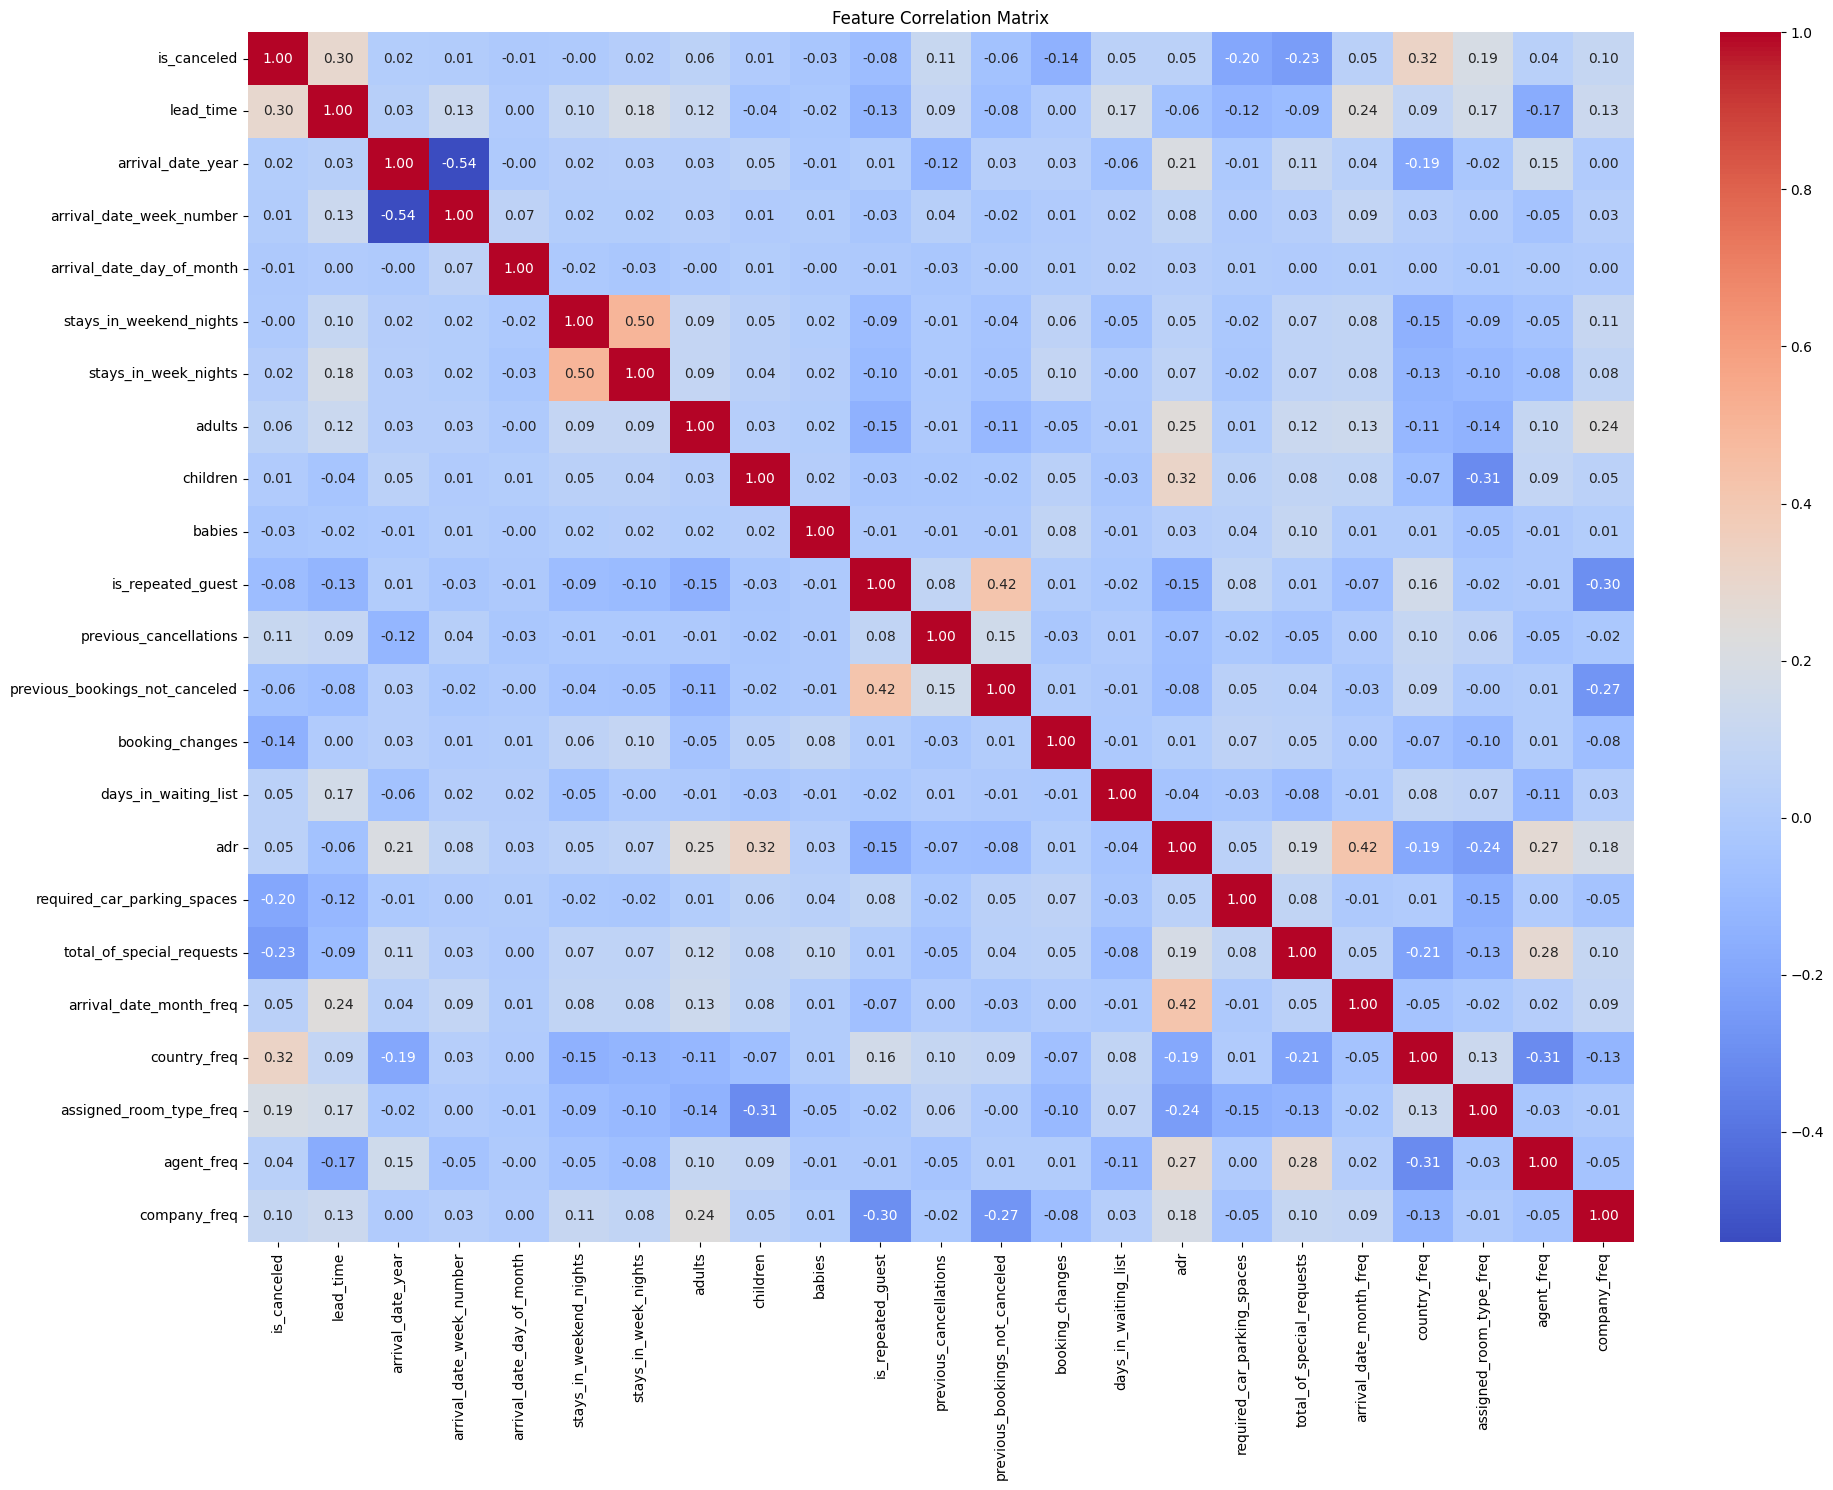

In [144]:
cat_cols = hb_capped.select_dtypes(include=['object', 'category']).columns
high_cardinality = [col for col in cat_cols if hb_capped[col].nunique() > 10]
low_cardinality  = [col for col in cat_cols if hb_capped[col].nunique() <= 10]

hb_encoded = hb_capped.copy()

for col in high_cardinality:
    freq = hb_encoded[col].value_counts(normalize=True)
    hb_encoded[f'{col}_freq'] = hb_encoded[col].map(freq)
    hb_encoded.drop(col, axis=1, inplace=True)

hb_encoded = pd.get_dummies(hb_encoded, columns=low_cardinality, drop_first=True)
numeric_hb = hb_encoded.select_dtypes(include=[np.number])

plt.figure(figsize=(20, 15))
sns.heatmap(numeric_hb.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

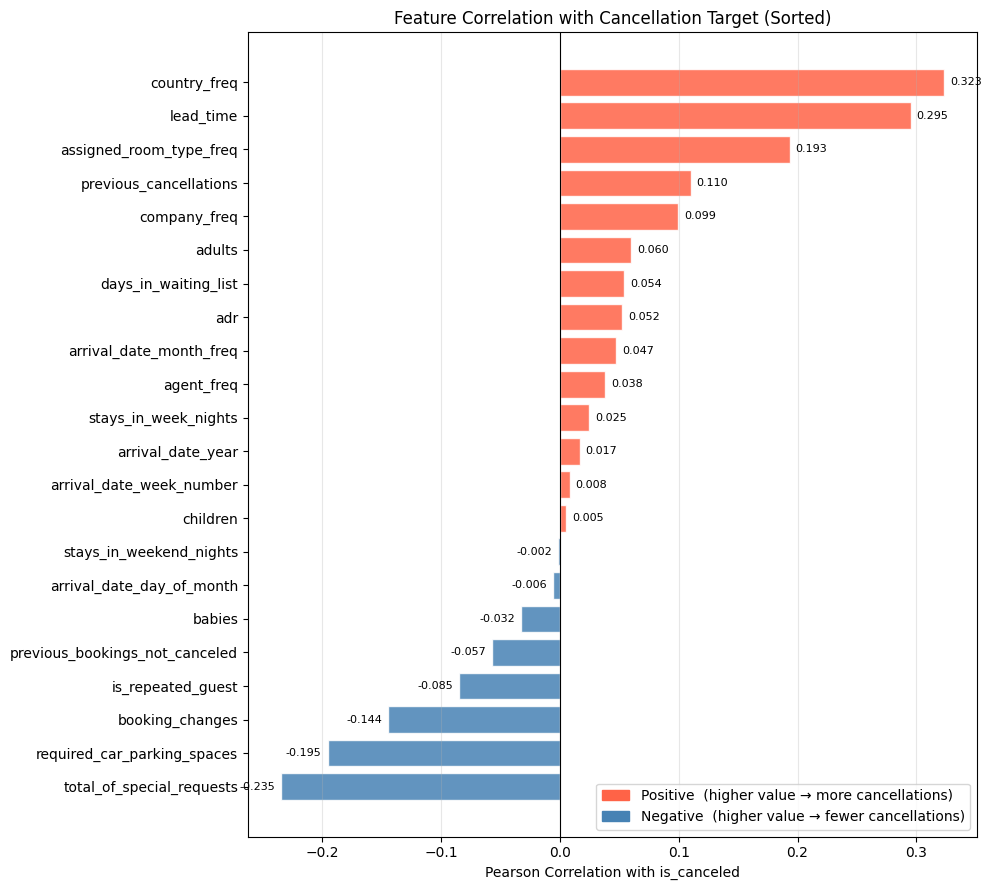

In [145]:
corr_target = numeric_hb.corr()['is_canceled'].drop('is_canceled').sort_values()
colors = ['tomato' if v > 0 else 'steelblue' for v in corr_target.values]

fig, ax = plt.subplots(figsize=(10, 9))
bars = ax.barh(corr_target.index, corr_target.values,
               color=colors, edgecolor='white', alpha=0.85)
ax.axvline(0, color='black', lw=0.8)

for bar, val in zip(bars, corr_target.values):
    xpos = val + 0.005 if val >= 0 else val - 0.005
    ha = 'left' if val >= 0 else 'right'
    ax.text(xpos, bar.get_y() + bar.get_height() / 2,
            f'{val:.3f}', va='center', ha=ha, fontsize=8)

ax.set_xlabel('Pearson Correlation with is_canceled')
ax.set_title('Feature Correlation with Cancellation Target (Sorted)', fontsize=12)
ax.grid(True, axis='x', alpha=0.3)
ax.legend(handles=[
    Patch(color='tomato',    label='Positive  (higher value → more cancellations)'),
    Patch(color='steelblue', label='Negative  (higher value → fewer cancellations)'),
], loc='lower right')
plt.tight_layout()
plt.show()

In [146]:
encoded_numeric = hb_encoded.select_dtypes(include=[np.number])
original_numeric = hb_capped.select_dtypes(include=[np.number])

remaining_cols = list(set(original_numeric.columns) - set(encoded_numeric.columns))
hb_final_numerical = pd.concat([encoded_numeric, original_numeric[remaining_cols]], axis=1)

print(f"Original shape : {hb_capped.shape}")
print(f"Final shape    : {hb_final_numerical.shape}")
print(f"All numeric    : {hb_final_numerical.select_dtypes(exclude=[np.number]).columns.tolist() == []}")

hb_final = hb_final_numerical.copy()
hb_final.head()

Original shape : (119390, 30)
Final shape    : (119390, 23)
All numeric    : True


,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,...,booking_changes,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests,arrival_date_month_freq,country_freq,assigned_room_type_freq,agent_freq,company_freq
0,0,342,2015,27,1,0,0,2,0.0,0,...,3,0,0.0,0,0,0.106047,0.406986,0.019893,0.136862,0.943069
1,0,373,2015,27,1,0,0,2,0.0,0,...,4,0,0.0,0,0,0.106047,0.406986,0.019893,0.136862,0.943069
2,0,7,2015,27,1,0,1,1,0.0,0,...,0,0,75.0,0,0,0.106047,0.101591,0.019893,0.136862,0.943069
3,0,13,2015,27,1,0,1,1,0.0,0,...,0,0,75.0,0,0,0.106047,0.101591,0.620261,0.000008,0.943069
4,0,14,2015,27,1,0,2,2,0.0,0,...,0,0,98.0,0,1,0.106047,0.101591,0.620261,0.116609,0.943069


## 6. Final Dataset Verification

Before moving to outlier analysis, we run a quality gate: every column must be numeric and every row must be complete. Anything that comes up here means going back to the cleaning step.

The null map below is the visual confirmation. All green means no missing values anywhere in the dataset.


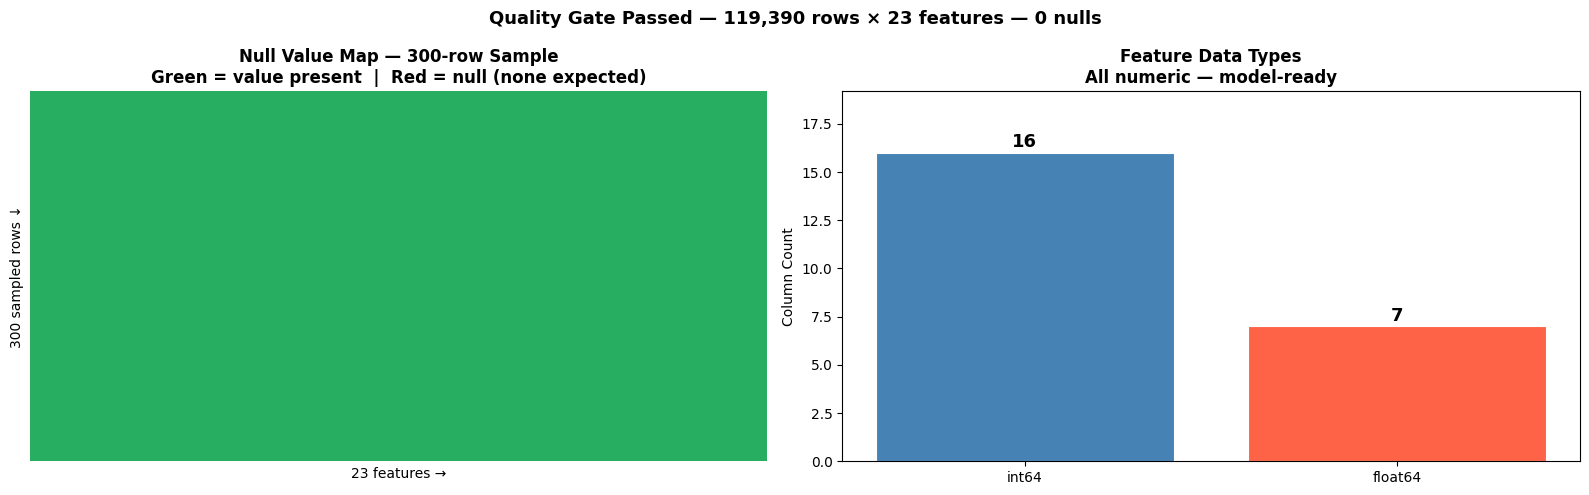

Shape  : (119390, 23)
Nulls  : 0 — all clear


In [147]:
null_counts = hb_final.isnull().sum()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Left: null heatmap over a 300-row sample
sample = hb_final.sample(min(300, len(hb_final)), random_state=42)
sns.heatmap(sample.isnull(), cmap=['#27ae60', '#e74c3c'],
            cbar=False, xticklabels=False, yticklabels=False, ax=axes[0])
axes[0].set_title('Null Value Map — 300-row Sample\n'
                  'Green = value present  |  Red = null (none expected)',
                  fontweight='bold')
axes[0].set_xlabel(f'{hb_final.shape[1]} features →')
axes[0].set_ylabel('300 sampled rows ↓')

# Right: dtype breakdown
dtype_counts = hb_final.dtypes.value_counts()
dtype_labels  = [str(d) for d in dtype_counts.index]
palette = ['steelblue', 'tomato', 'seagreen', 'darkorange']
bars = axes[1].bar(dtype_labels, dtype_counts.values,
                   color=palette[:len(dtype_counts)], edgecolor='white', linewidth=0.8)
for bar, cnt in zip(bars, dtype_counts.values):
    axes[1].text(bar.get_x() + bar.get_width() / 2, cnt + 0.3,
                 str(cnt), ha='center', fontweight='bold', fontsize=13)
axes[1].set_title('Feature Data Types\nAll numeric — model-ready', fontweight='bold')
axes[1].set_ylabel('Column Count')
axes[1].set_ylim(0, dtype_counts.max() * 1.2)

plt.suptitle(
    f'Quality Gate Passed — {hb_final.shape[0]:,} rows × {hb_final.shape[1]} features'
    f' — {null_counts.sum()} nulls',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.show()

print(f'Shape  : {hb_final.shape}')
print(f'Nulls  : {null_counts.sum()} — all clear')


## 7. Univariate Outlier Analysis

Capping in Section 4 brought extreme values under control. Here we go further and remove statistically anomalous records using two independent methods applied across all key continuous columns.

**Z-score:** Measures how far a value sits from the column mean in standard deviation units. Anything beyond 3 standard deviations gets flagged. Works well for roughly normal distributions.

**Modified Z-score (MAD):** Uses the median and median absolute deviation instead of the mean and standard deviation. This makes it robust to the very outliers it is detecting. Threshold: 3.5.

A booking is only removed if both methods flag it. This conservative rule keeps the dataset as large as possible while still cutting the most clearly anomalous records.


In [148]:
cols_zscore = [
    'lead_time', 'stays_in_weekend_nights', 'stays_in_week_nights',
    'adults', 'children', 'babies', 'days_in_waiting_list', 'adr',
    'previous_cancellations', 'previous_bookings_not_canceled',
    'booking_changes', 'total_of_special_requests'
]

# --- Z-Score (|z| > 3) ---
z_scores = np.abs(stats.zscore(hb_final[cols_zscore]))
z_df = pd.DataFrame(z_scores, columns=cols_zscore)
z_mask = (z_df > 3).any(axis=1)

print("=== Z-Score Outliers (|z| > 3) ===")
print(f"Total rows flagged : {z_mask.sum()} ({z_mask.mean()*100:.2f}%)")
print("\nPer-column count:")
print((z_df > 3).sum().to_string())

# --- Modified Z-Score using MAD (|Mz| > 3.5) ---
def modified_zscore(series):
    median = series.median()
    mad = (series - median).abs().median()
    if mad == 0:
        return pd.Series(np.zeros(len(series)), index=series.index)
    return 0.6745 * (series - median).abs() / mad

mod_z_df = pd.DataFrame({col: modified_zscore(hb_final[col]) for col in cols_zscore})
mod_z_mask = (mod_z_df > 3.5).any(axis=1)

print("\n=== Modified Z-Score Outliers (|Mz| > 3.5) ===")
print(f"Total rows flagged : {mod_z_mask.sum()} ({mod_z_mask.mean()*100:.2f}%)")
print("\nPer-column count:")
print((mod_z_df > 3.5).sum().to_string())

# --- Conservative removal: only rows flagged by BOTH ---
both_mask = z_mask & mod_z_mask
print(f"\n=== Consensus outliers (both methods): {both_mask.sum()} rows ({both_mask.mean()*100:.2f}%) ===")
hb_clean = hb_final[~both_mask].reset_index(drop=True)
print(f"Dataset after univariate outlier removal: {hb_clean.shape}")

=== Z-Score Outliers (|z| > 3) ===
Total rows flagged : 13804 (11.56%)

Per-column count:
lead_time                            0
stays_in_weekend_nights           2199
stays_in_week_nights              1669
adults                             481
children                          3729
babies                             917
days_in_waiting_list              1871
adr                                  0
previous_cancellations             317
previous_bookings_not_canceled     936
booking_changes                   1570
total_of_special_requests         2877

=== Modified Z-Score Outliers (|Mz| > 3.5) ===
Total rows flagged : 2325 (1.95%)

Per-column count:
lead_time                            0
stays_in_weekend_nights            112
stays_in_week_nights              2325
adults                               0
children                             0
babies                               0
days_in_waiting_list                 0
adr                                  0
previous_cancellations       

/var/folders/lc/x5lgkj591sb74r0q10tqtmj40000gq/T/ipykernel_6010/4127937319.py:20: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(


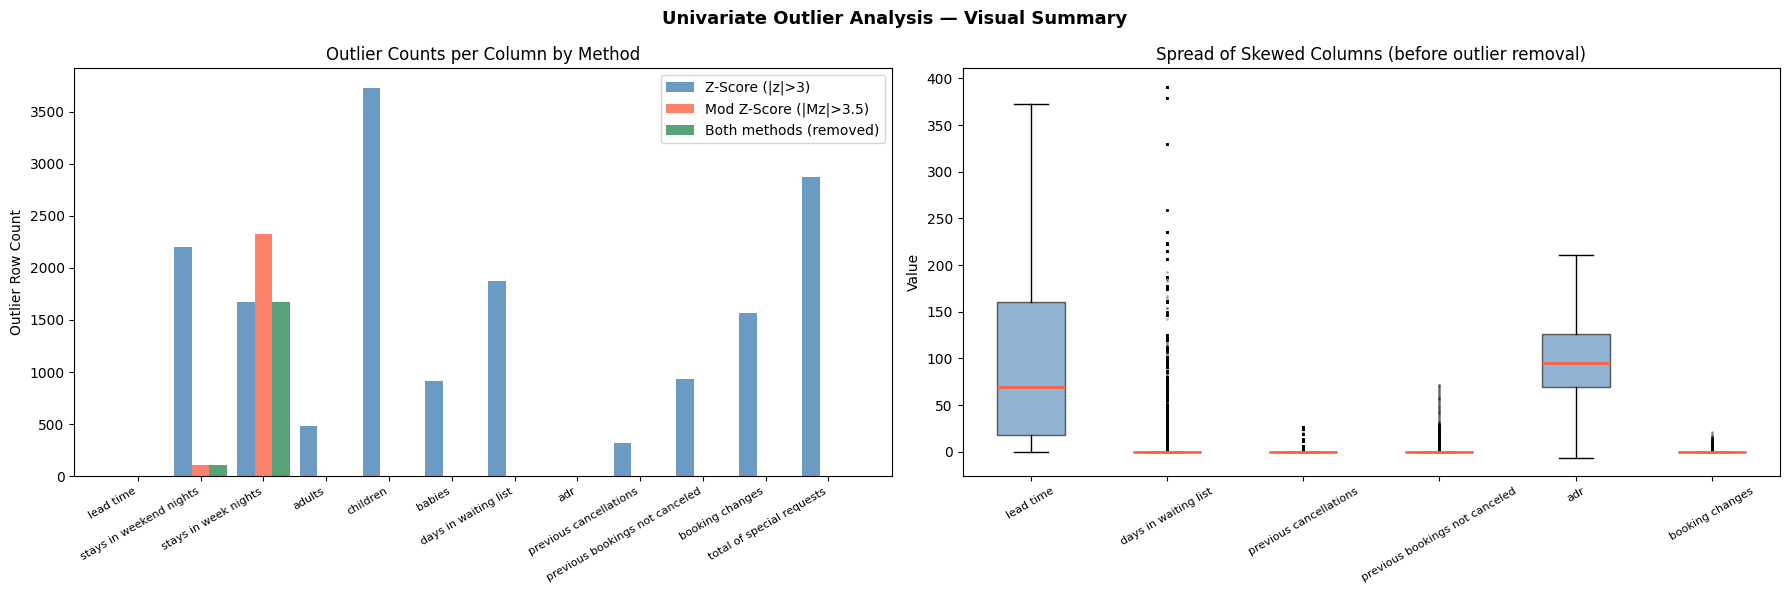

In [149]:
z_counts    = (z_df > 3).sum()
mz_counts   = (mod_z_df > 3.5).sum()
both_counts = ((z_df > 3) & (mod_z_df > 3.5)).sum()
x, width = np.arange(len(cols_zscore)), 0.28

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

axes[0].bar(x - width, z_counts.values,    width, label='Z-Score (|z|>3)',         color='steelblue', alpha=0.8)
axes[0].bar(x,         mz_counts.values,   width, label='Mod Z-Score (|Mz|>3.5)',  color='tomato',    alpha=0.8)
axes[0].bar(x + width, both_counts.values, width, label='Both methods (removed)',   color='seagreen',  alpha=0.8)
axes[0].set_xticks(x)
axes[0].set_xticklabels([c.replace('_', ' ') for c in cols_zscore],
                        rotation=30, ha='right', fontsize=8)
axes[0].set_ylabel('Outlier Row Count')
axes[0].set_title('Outlier Counts per Column by Method')
axes[0].legend()

skewed_cols = ['lead_time', 'days_in_waiting_list', 'previous_cancellations',
               'previous_bookings_not_canceled', 'adr', 'booking_changes']
axes[1].boxplot(
    [hb_final[col].dropna() for col in skewed_cols],
    labels=[c.replace('_', ' ') for c in skewed_cols],
    patch_artist=True,
    boxprops=dict(facecolor='steelblue', alpha=0.6),
    medianprops=dict(color='tomato', lw=2),
    flierprops=dict(marker='.', alpha=0.3, markersize=2),
    widths=0.5
)
axes[1].set_title('Spread of Skewed Columns (before outlier removal)')
axes[1].set_ylabel('Value')
axes[1].tick_params(axis='x', rotation=30, labelsize=8)

plt.suptitle('Univariate Outlier Analysis — Visual Summary', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 8. Multivariate Outlier Analysis

A booking can look perfectly normal on any single feature and still be an unusual combination of values. A very long lead time paired with zero special requests, a non-refundable deposit, and no prior stays might be ordinary on each axis but rare as a combined profile.

**Mahalanobis distance** catches this. It measures how far a data point sits from the centre of the full feature distribution, accounting for the correlations between features. Points beyond the 99.9th percentile of the chi-squared distribution are flagged and removed.

The dataset that passes this step, `hb_final_clean`, is what both models are trained on.


=== Mahalanobis Distance Outliers ===
Chi-squared threshold  (df=10, p=0.001) : 29.59
Rows flagged           : 2561 (2.18%)


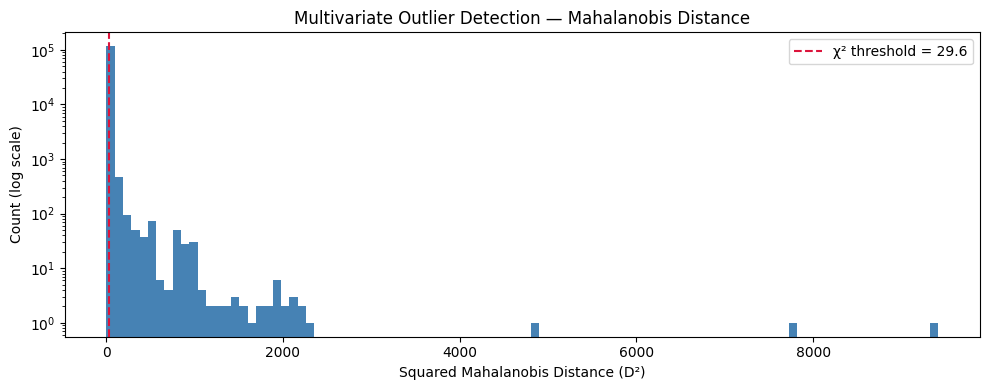


Final cleaned dataset : (114967, 23)
Cancellation rate     : 0.3716


,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,...,booking_changes,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests,arrival_date_month_freq,country_freq,assigned_room_type_freq,agent_freq,company_freq
0,0,7,2015,27,1,0,1,1,0.0,0,...,0,0,75.0,0,0,0.106047,0.101591,0.019893,0.136862,0.943069
1,0,13,2015,27,1,0,1,1,0.0,0,...,0,0,75.0,0,0,0.106047,0.101591,0.620261,0.000008,0.943069
2,0,14,2015,27,1,0,2,2,0.0,0,...,0,0,98.0,0,1,0.106047,0.101591,0.620261,0.116609,0.943069
3,0,14,2015,27,1,0,2,2,0.0,0,...,0,0,98.0,0,1,0.106047,0.101591,0.620261,0.116609,0.943069
4,0,0,2015,27,1,0,2,2,0.0,0,...,0,0,107.0,0,0,0.106047,0.406986,0.019893,0.136862,0.943069


In [150]:
mv_cols = [
    'lead_time', 'stays_in_weekend_nights', 'stays_in_week_nights',
    'adults', 'days_in_waiting_list', 'adr',
    'previous_cancellations', 'previous_bookings_not_canceled',
    'booking_changes', 'total_of_special_requests'
]

X_mv = hb_clean[mv_cols].values.astype(float)
mean_vec = X_mv.mean(axis=0)
VI = np.linalg.inv(np.cov(X_mv, rowvar=False))

# Vectorized squared Mahalanobis distance: D^2 = (x - mu)^T * VI * (x - mu)
diff = X_mv - mean_vec
mahal_sq = np.einsum('ij,jk,ik->i', diff, VI, diff)

threshold_sq = chi2.ppf(0.999, df=len(mv_cols))
mahal_outliers = mahal_sq > threshold_sq

print("=== Mahalanobis Distance Outliers ===")
print(f"Chi-squared threshold  (df={len(mv_cols)}, p=0.001) : {threshold_sq:.2f}")
print(f"Rows flagged           : {mahal_outliers.sum()} ({mahal_outliers.mean()*100:.2f}%)")

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(mahal_sq, bins=100, color='steelblue', edgecolor='none', log=True)
ax.axvline(threshold_sq, color='crimson', linestyle='--', label=f'χ² threshold = {threshold_sq:.1f}')
ax.set_xlabel('Squared Mahalanobis Distance (D²)')
ax.set_ylabel('Count (log scale)')
ax.set_title('Multivariate Outlier Detection — Mahalanobis Distance')
ax.legend()
plt.tight_layout()
plt.show()

hb_final_clean = hb_clean[~mahal_outliers].reset_index(drop=True)
print(f"\nFinal cleaned dataset : {hb_final_clean.shape}")
print(f"Cancellation rate     : {hb_final_clean['is_canceled'].mean():.4f}")
hb_final_clean.head()

## 9. Cancellation Prediction Model: Logistic Regression

With clean, encoded data in hand, we build the first model: a binary classifier that predicts whether a booking will cancel.

**Why Logistic Regression?** It produces calibrated probabilities. The score it outputs for each booking genuinely reflects the likelihood of cancellation, not just a relative ranking. That calibration matters because those probability scores feed directly into the severity tier labels in Section 12.

**Training process:**
1. 80/20 stratified split, preserving the cancellation rate in both sets
2. Normalise features with `StandardScaler`, fitted on training data only (fitting on test data would be leakage)
3. Train and evaluate on the held-out test set

**What we care about most:** Recall on the cancelled class. Missing a likely cancellation means a room goes unprotected and revenue is lost. A false alarm just means a retention effort that was not needed, which is a much cheaper error.


In [151]:
X = hb_final_clean.drop(columns=['is_canceled'])
y = hb_final_clean['is_canceled']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f"Training set  : {X_train_scaled.shape}")
print(f"Test set      : {X_test_scaled.shape}")
print(f"\nClass distribution (train):")
print(pd.Series(y_train).value_counts(normalize=True)
      .rename({0: 'not cancelled', 1: 'cancelled'}).to_string())

Training set  : (91973, 22)
Test set      : (22994, 22)

Class distribution (train):
is_canceled
not cancelled    0.628413
cancelled        0.371587


In [152]:
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_scaled, y_train)

y_pred = lr.predict(X_test_scaled)
y_prob = lr.predict_proba(X_test_scaled)[:, 1]

print("=== Classification Report (test set) ===")
print(classification_report(y_test, y_pred, target_names=['Not Cancelled', 'Cancelled']))

print(f"ROC-AUC Score           : {roc_auc_score(y_test, y_prob):.4f}")
print(f"Avg Precision (PR area) : {average_precision_score(y_test, y_prob):.4f}")

# Macro summaries for quick reference
print(f"\nPrecision (macro) : {precision_score(y_test, y_pred, average='macro'):.4f}")
print(f"Recall    (macro) : {recall_score(y_test, y_pred, average='macro'):.4f}")
print(f"F1        (macro) : {f1_score(y_test, y_pred, average='macro'):.4f}")

=== Classification Report (test set) ===
               precision    recall  f1-score   support

Not Cancelled       0.82      0.87      0.84     14450
    Cancelled       0.75      0.68      0.71      8544

     accuracy                           0.80     22994
    macro avg       0.78      0.77      0.78     22994
 weighted avg       0.79      0.80      0.79     22994

ROC-AUC Score           : 0.8677
Avg Precision (PR area) : 0.8072

Precision (macro) : 0.7849
Recall    (macro) : 0.7718
F1        (macro) : 0.7771


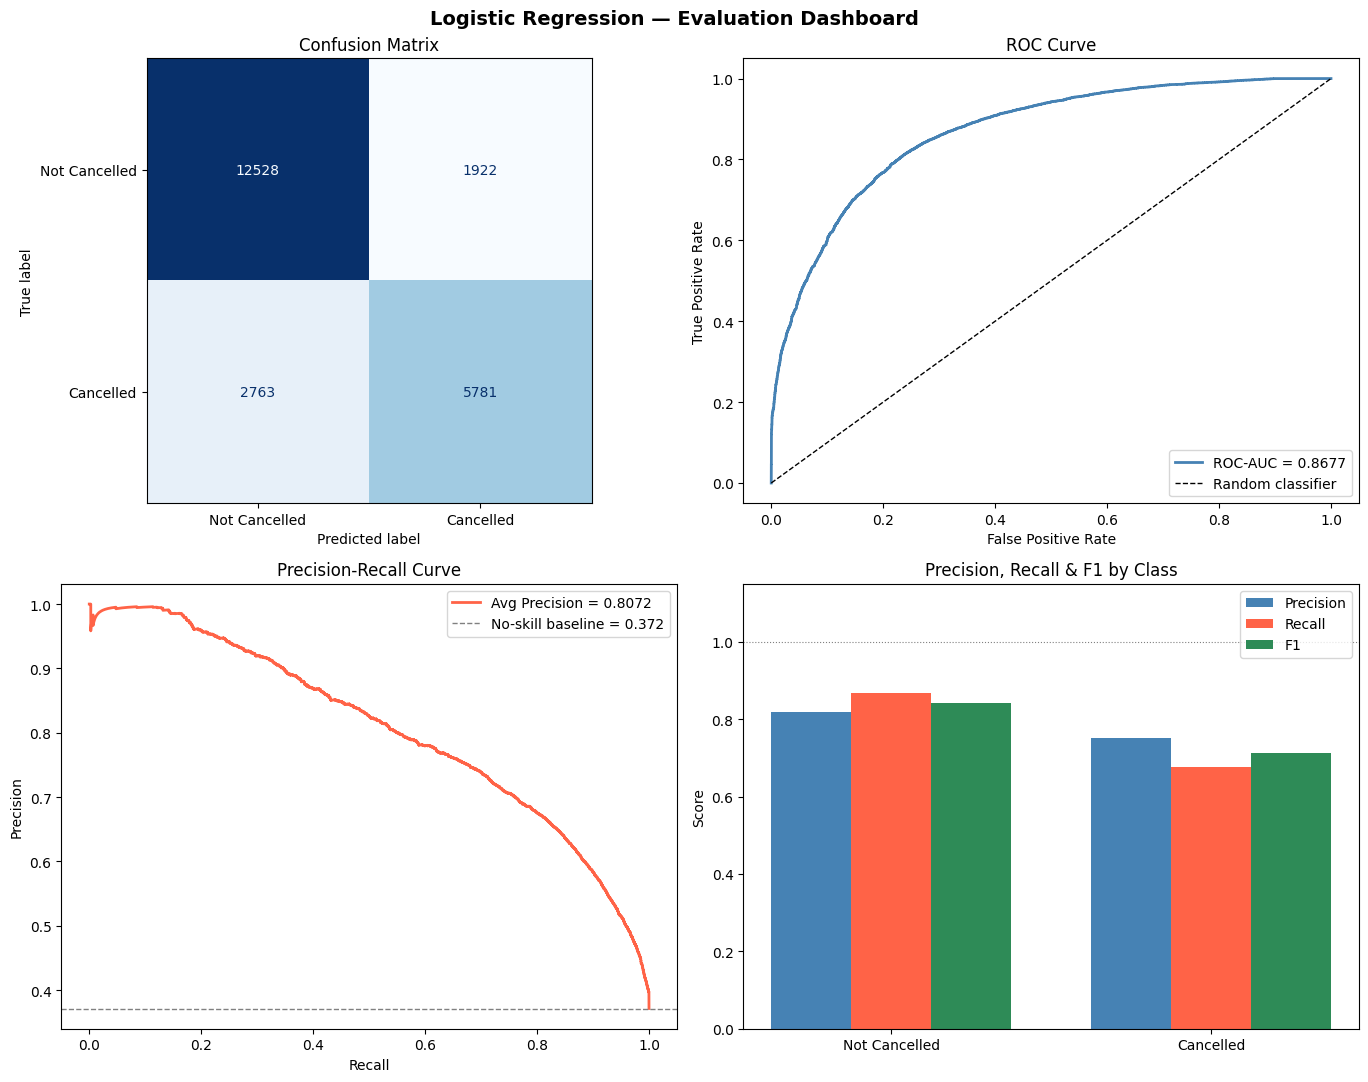

In [153]:
report = classification_report(y_test, y_pred, output_dict=True)
fpr, tpr, _          = roc_curve(y_test, y_prob)
prec_vals, rec_vals, _ = precision_recall_curve(y_test, y_prob)
auc  = roc_auc_score(y_test, y_prob)
ap   = average_precision_score(y_test, y_prob)

fig, axes = plt.subplots(2, 2, figsize=(14, 11))

# ── Confusion matrix ──────────────────────────────────────────────────────────
ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_pred),
    display_labels=['Not Cancelled', 'Cancelled']
).plot(ax=axes[0, 0], cmap='Blues', colorbar=False)
axes[0, 0].set_title('Confusion Matrix')

# ── ROC curve ─────────────────────────────────────────────────────────────────
axes[0, 1].plot(fpr, tpr, color='steelblue', lw=2, label=f'ROC-AUC = {auc:.4f}')
axes[0, 1].plot([0, 1], [0, 1], 'k--', lw=1, label='Random classifier')
axes[0, 1].set_xlabel('False Positive Rate')
axes[0, 1].set_ylabel('True Positive Rate')
axes[0, 1].set_title('ROC Curve')
axes[0, 1].legend(loc='lower right')

# ── Precision-Recall curve ────────────────────────────────────────────────────
axes[1, 0].plot(rec_vals, prec_vals, color='tomato', lw=2, label=f'Avg Precision = {ap:.4f}')
axes[1, 0].axhline(y_test.mean(), color='gray', linestyle='--', lw=1,
                   label=f'No-skill baseline = {y_test.mean():.3f}')
axes[1, 0].set_xlabel('Recall')
axes[1, 0].set_ylabel('Precision')
axes[1, 0].set_title('Precision-Recall Curve')
axes[1, 0].legend(loc='upper right')

# ── Per-class bar chart: precision / recall / F1 ─────────────────────────────
classes = ['Not Cancelled', 'Cancelled']
metrics = [('precision', 'steelblue'), ('recall', 'tomato'), ('f1-score', 'seagreen')]
x, width = np.arange(len(classes)), 0.25

for i, (metric, colour) in enumerate(metrics):
    vals = [report['0'][metric], report['1'][metric]]
    axes[1, 1].bar(x + i * width, vals, width,
                   label=metric.replace('-score', '').title(), color=colour)

axes[1, 1].set_xticks(x + width)
axes[1, 1].set_xticklabels(classes)
axes[1, 1].set_ylim(0, 1.15)
axes[1, 1].axhline(1.0, color='gray', linestyle=':', lw=0.8)
axes[1, 1].set_ylabel('Score')
axes[1, 1].set_title('Precision, Recall & F1 by Class')
axes[1, 1].legend()

plt.suptitle('Logistic Regression — Evaluation Dashboard', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 10. Overfitting Check: Learning Curve

A model that performs well on training data but poorly on new bookings is useless in production. The learning curve plots F1 score against increasing training set sizes using 5-fold cross-validation to simulate performance on data the model has not seen.

| Pattern | Diagnosis |
|---------|----------|
| High training score, low validation score, large gap | Overfitting: the model memorised the training set |
| Both scores low at all training sizes | Underfitting: the model is too simple |
| Curves converge as training size grows | Good fit: the model is learning real patterns |

We want the curves to converge. Shaded bands show the variance across folds.


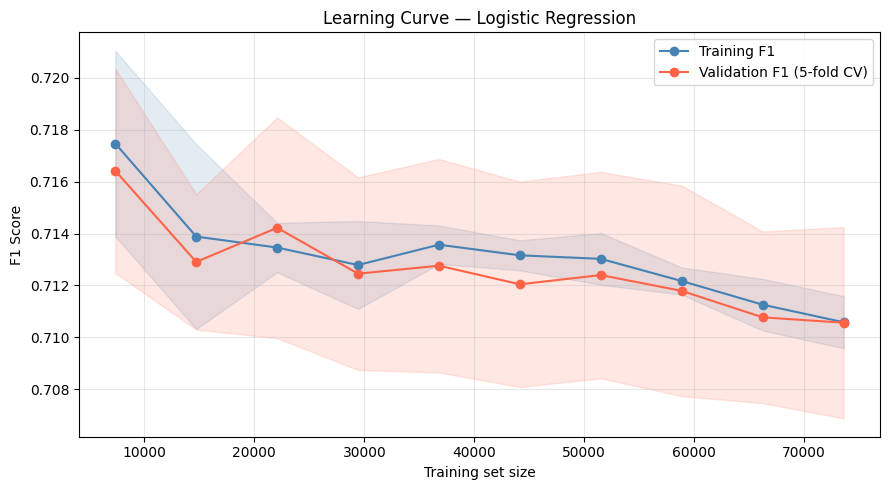

Train F1 (full data)  : 0.7106
Val F1  (5-fold CV)   : 0.7106
Train / Val gap       : 0.0000
→ Curves converge with a small gap — no significant overfitting detected.


In [154]:
train_sizes, train_scores, val_scores = learning_curve(
    LogisticRegression(max_iter=1000, random_state=42),
    X_train_scaled, y_train,
    train_sizes=np.linspace(0.1, 1.0, 10),
    cv=5, scoring='f1', n_jobs=-1,
)

tr_mean, tr_std = train_scores.mean(axis=1), train_scores.std(axis=1)
vl_mean, vl_std = val_scores.mean(axis=1),   val_scores.std(axis=1)

plt.figure(figsize=(9, 5))
plt.plot(train_sizes, tr_mean, 'o-', color='steelblue', label='Training F1')
plt.fill_between(train_sizes, tr_mean - tr_std, tr_mean + tr_std, alpha=0.15, color='steelblue')
plt.plot(train_sizes, vl_mean, 'o-', color='tomato',    label='Validation F1 (5-fold CV)')
plt.fill_between(train_sizes, vl_mean - vl_std, vl_mean + vl_std, alpha=0.15, color='tomato')
plt.xlabel('Training set size')
plt.ylabel('F1 Score')
plt.title('Learning Curve — Logistic Regression')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

gap = tr_mean[-1] - vl_mean[-1]
print(f"Train F1 (full data)  : {tr_mean[-1]:.4f}")
print(f"Val F1  (5-fold CV)   : {vl_mean[-1]:.4f}")
print(f"Train / Val gap       : {gap:.4f}")
if gap > 0.05:
    print("→ Notable gap — consider stronger regularisation (lower C in LogisticRegression).")
elif vl_mean[-1] < 0.60:
    print("→ Both scores low — model may be underfitting; consider more features or a non-linear model.")
else:
    print("→ Curves converge with a small gap — no significant overfitting detected.")

## 11. Class Imbalance Assessment

If the data contains far more non-cancellations than cancellations, a model that always predicts "not cancelled" would score well on accuracy while being completely useless for our purpose. Before trusting any metric, we check how balanced the classes actually are.

| Ratio | Assessment | Action |
|-------|------------|--------|
| Below 1.5x | Balanced | No adjustment needed |
| 1.5x to 3x | Mild | Apply `class_weight='balanced'` |
| Above 3x | Severe | SMOTE or resampling required |

This also matters for the severity tier model coming up, where the four tiers will be distributed even more unevenly than the binary labels.


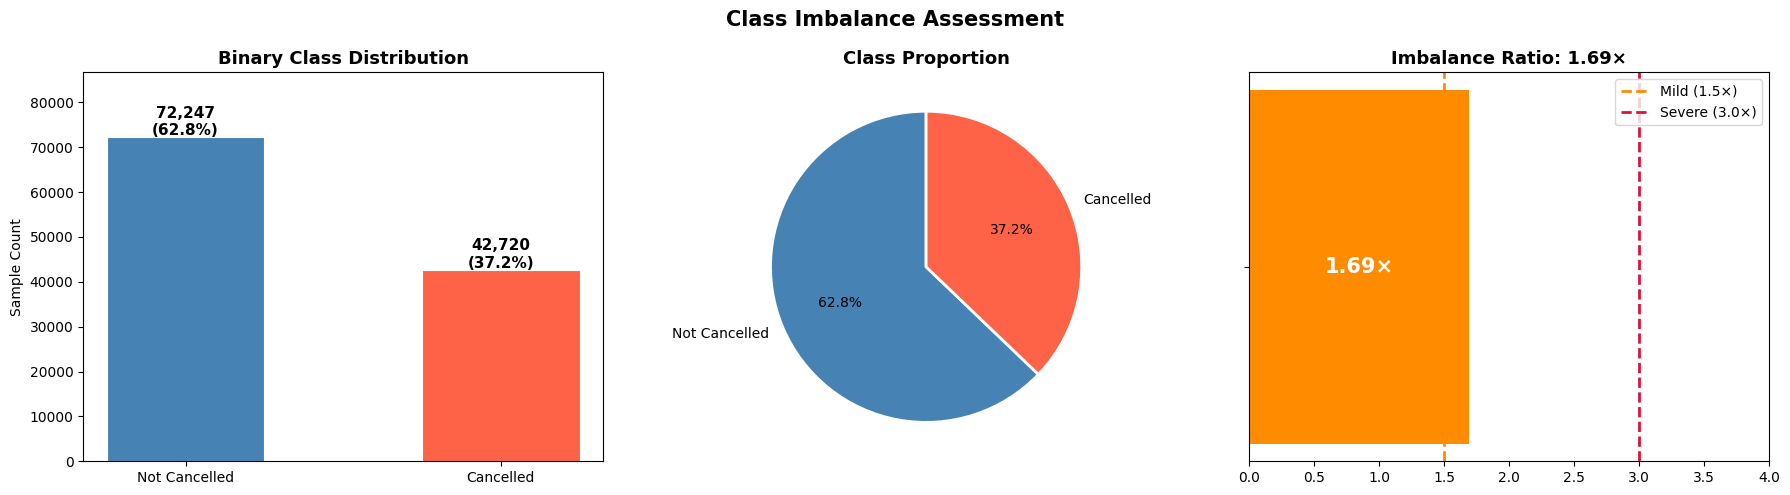

Mild imbalance (1.69×) — class_weight='balanced' is sufficient.


In [155]:
cancel_counts   = y.value_counts().sort_index()
cancel_pct      = y.value_counts(normalize=True).sort_index() * 100
imbalance_ratio = cancel_counts.max() / cancel_counts.min()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

bars = axes[0].bar(['Not Cancelled', 'Cancelled'], cancel_counts.values,
                   color=['steelblue', 'tomato'], edgecolor='white', linewidth=0.8, width=0.5)
for bar, cnt, pct in zip(bars, cancel_counts.values, cancel_pct.values):
    axes[0].text(bar.get_x() + bar.get_width() / 2, cnt + 400,
                 f'{cnt:,}\n({pct:.1f}%)', ha='center', fontsize=11, fontweight='bold')
axes[0].set_title('Binary Class Distribution', fontweight='bold', fontsize=13)
axes[0].set_ylabel('Sample Count')
axes[0].set_ylim(0, cancel_counts.max() * 1.2)

axes[1].pie(cancel_counts.values, labels=['Not Cancelled', 'Cancelled'],
            colors=['steelblue', 'tomato'], autopct='%1.1f%%', startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Class Proportion', fontweight='bold', fontsize=13)

bar_color = ('seagreen' if imbalance_ratio < 1.5 else
             'darkorange' if imbalance_ratio < 3.0 else 'crimson')
axes[2].barh([''], [imbalance_ratio], color=bar_color, height=0.4)
axes[2].axvline(1.5, color='darkorange', linestyle='--', lw=2, label='Mild (1.5×)')
axes[2].axvline(3.0, color='crimson',    linestyle='--', lw=2, label='Severe (3.0×)')
axes[2].set_xlim(0, max(imbalance_ratio * 1.3, 4))
axes[2].text(imbalance_ratio / 2, 0, f'{imbalance_ratio:.2f}×',
             ha='center', va='center', fontsize=15, fontweight='bold', color='white')
axes[2].set_title(f'Imbalance Ratio: {imbalance_ratio:.2f}×', fontweight='bold', fontsize=13)
axes[2].legend()

plt.suptitle('Class Imbalance Assessment', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

verdict = (
    f"Severe imbalance ({imbalance_ratio:.2f}×) — SMOTE or class_weight='balanced' strongly recommended."
    if imbalance_ratio >= 3.0 else
    f"Mild imbalance ({imbalance_ratio:.2f}×) — class_weight='balanced' is sufficient."
    if imbalance_ratio >= 1.5 else
    f"Classes are balanced ({imbalance_ratio:.2f}×) — no adjustment needed."
)
print(verdict)


## 12. Cancellation Severity Scoring

A binary yes/no prediction tells us a booking might cancel. It does not tell us whether to send an email or pick up the phone. For that, we need a severity scale.

We use the Logistic Regression probability to assign each booking to one of four tiers:

| Tier | Probability | Signal | Response |
|------|-------------|--------|----------|
| 0: Very Unlikely | 0.0 to 0.2 | Standard booking | No action |
| 1: Unlikely | 0.3 to 0.5 | May reschedule or delay | Monitor, re-confirm closer to date |
| 2: Likely | 0.6 to 0.8 | Cancellation probable | Proactive offer: upgrade, discount, or freebie |
| 3: Most Likely | 0.9 to 1.0 | Near-certain cancellation | Immediate retention call, prepare for re-marketing |

**On label quality:** The training-set severity labels are generated using 5-fold cross-validation, not direct LR predictions on the training data. This prevents the XGBoost model from inheriting whatever errors the LR made on its own training set.


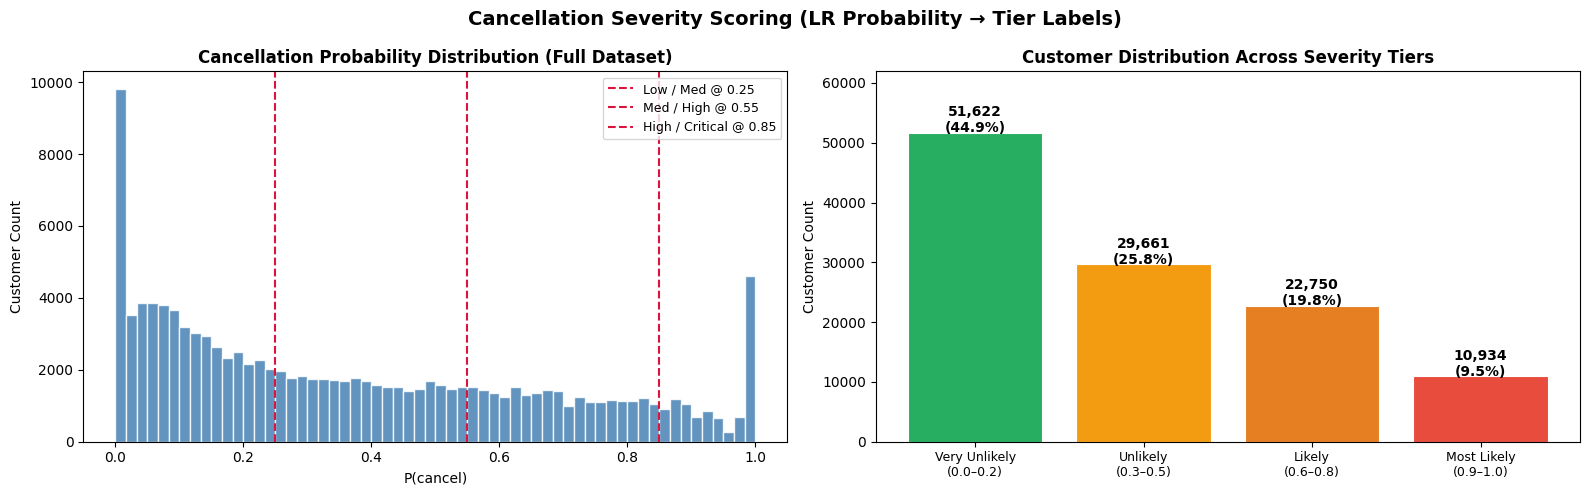


Severity Tier Action Guide
──────────────────────────────────────────────────────────────
  Tier 0  Very Unlikely (0.0–0.2)           →  Standard booking — no intervention needed.
  Tier 1  Unlikely (0.3–0.5)                →  Monitor: customer may delay arrival or move check-in date.
  Tier 2  Likely (0.6–0.8)                  →  Proactive outreach: offer discounts, upgrades or freebies to retain.
  Tier 3  Most Likely (0.9–1.0)             →  High-risk: immediate retention action or prepare for vacancy.

Train severity distribution:
Very Unlikely    41319
Unlikely         23757
Likely           18167
Most Likely       8730
Name: count, dtype: int64


In [156]:
SEVERITY_BINS    = [0.0, 0.25, 0.55, 0.85, 1.01]
SEVERITY_LABELS  = ['Very Unlikely\n(0.0–0.2)', 'Unlikely\n(0.3–0.5)',
                    'Likely\n(0.6–0.8)', 'Most Likely\n(0.9–1.0)']
SEVERITY_COLORS  = ['#27ae60', '#f39c12', '#e67e22', '#e74c3c']
SEVERITY_ACTIONS = [
    'Standard booking — no intervention needed.',
    'Monitor: customer may delay arrival or move check-in date.',
    'Proactive outreach: offer discounts, upgrades or freebies to retain.',
    'High-risk: immediate retention action or prepare for vacancy.',
]

# Full-dataset probability → tier (for visualisation; uses train-fit scaler — correct)
proba_full = lr.predict_proba(scaler.transform(X))[:, 1]
sev_full   = pd.cut(proba_full, bins=SEVERITY_BINS, labels=[0, 1, 2, 3]).astype(int)

# Unbiased train-set labels via 5-fold out-of-fold LR probabilities
lr_cv          = LogisticRegression(max_iter=1000, random_state=42)
proba_train_cv = cross_val_predict(lr_cv, X_train_scaled, y_train,
                                   cv=5, method='predict_proba')[:, 1]
y_train_sev = pd.cut(proba_train_cv, bins=SEVERITY_BINS, labels=[0, 1, 2, 3]).astype(int)
y_test_sev  = pd.cut(y_prob,         bins=SEVERITY_BINS, labels=[0, 1, 2, 3]).astype(int)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].hist(proba_full, bins=60, color='steelblue', edgecolor='white', alpha=0.85)
for cut, lbl in zip([0.25, 0.55, 0.85], ['Low / Med', 'Med / High', 'High / Critical']):
    axes[0].axvline(cut, color='crimson', linestyle='--', lw=1.5, label=f'{lbl} @ {cut}')
axes[0].set_title('Cancellation Probability Distribution (Full Dataset)', fontweight='bold')
axes[0].set_xlabel('P(cancel)')
axes[0].set_ylabel('Customer Count')
axes[0].legend(fontsize=9)

sev_counts = pd.Series(sev_full).value_counts().sort_index()
bars = axes[1].bar(range(4), sev_counts.values, color=SEVERITY_COLORS,
                   edgecolor='white', linewidth=0.8)
for bar, cnt in zip(bars, sev_counts.values):
    pct = cnt / len(sev_full) * 100
    axes[1].text(bar.get_x() + bar.get_width() / 2, cnt + 100,
                 f'{cnt:,}\n({pct:.1f}%)', ha='center', fontsize=10, fontweight='bold')
axes[1].set_xticks(range(4))
axes[1].set_xticklabels(SEVERITY_LABELS, fontsize=9)
axes[1].set_title('Customer Distribution Across Severity Tiers', fontweight='bold')
axes[1].set_ylabel('Customer Count')
axes[1].set_ylim(0, sev_counts.max() * 1.2)

plt.suptitle('Cancellation Severity Scoring (LR Probability → Tier Labels)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('\nSeverity Tier Action Guide')
print('─' * 62)
for i, (lbl, action) in enumerate(zip(SEVERITY_LABELS, SEVERITY_ACTIONS)):
    print(f"  Tier {i}  {lbl.replace(chr(10), ' '):<32}  →  {action}")

print('\nTrain severity distribution:')
print(pd.Series(y_train_sev).value_counts().sort_index()
        .rename(dict(enumerate(['Very Unlikely', 'Unlikely', 'Likely', 'Most Likely']))))


## 13. Severity Classification Model: XGBoost

This is the second model. Where Logistic Regression draws a straight line through the feature space, XGBoost builds an ensemble of decision trees that capture non-linear interactions. A booking's severity tier is often determined by how multiple features combine, not any single feature alone. That is the problem XGBoost is designed for.

**Why XGBoost specifically:**
- Our feature set after Mahalanobis cleaning is compact. Gradient-boosted trees perform best in exactly this regime.
- `multi:softprob` returns a full probability distribution over all four tiers, not just a class label.
- Class weights at training time correct for tier imbalance.

**What the model returns per booking:**
- The predicted severity tier (0, 1, 2, or 3)
- A confidence score for each tier

The evaluation below covers the confusion matrix, per-tier precision and recall, feature importances, confidence distributions, precision-recall curves, and a learning curve.


In [157]:
sample_weights = compute_sample_weight('balanced', y_train_sev)

xgb_model = XGBClassifier(
    objective='multi:softprob',
    num_class=4,
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    eval_metric='mlogloss',
    verbosity=0,
)
xgb_model.fit(X_train_scaled, y_train_sev, sample_weight=sample_weights)

y_pred_sev  = xgb_model.predict(X_test_scaled)
y_proba_sev = xgb_model.predict_proba(X_test_scaled)

tier_names = ['Very Unlikely', 'Unlikely', 'Likely', 'Most Likely']
print('=== XGBoost Severity Classifier — Classification Report ===')
print(classification_report(y_test_sev, y_pred_sev, target_names=tier_names))


=== XGBoost Severity Classifier — Classification Report ===
               precision    recall  f1-score   support

Very Unlikely       0.99      0.96      0.97     10295
     Unlikely       0.90      0.95      0.93      5907
       Likely       0.95      0.95      0.95      4570
  Most Likely       0.98      0.98      0.98      2222

     accuracy                           0.96     22994
    macro avg       0.96      0.96      0.96     22994
 weighted avg       0.96      0.96      0.96     22994



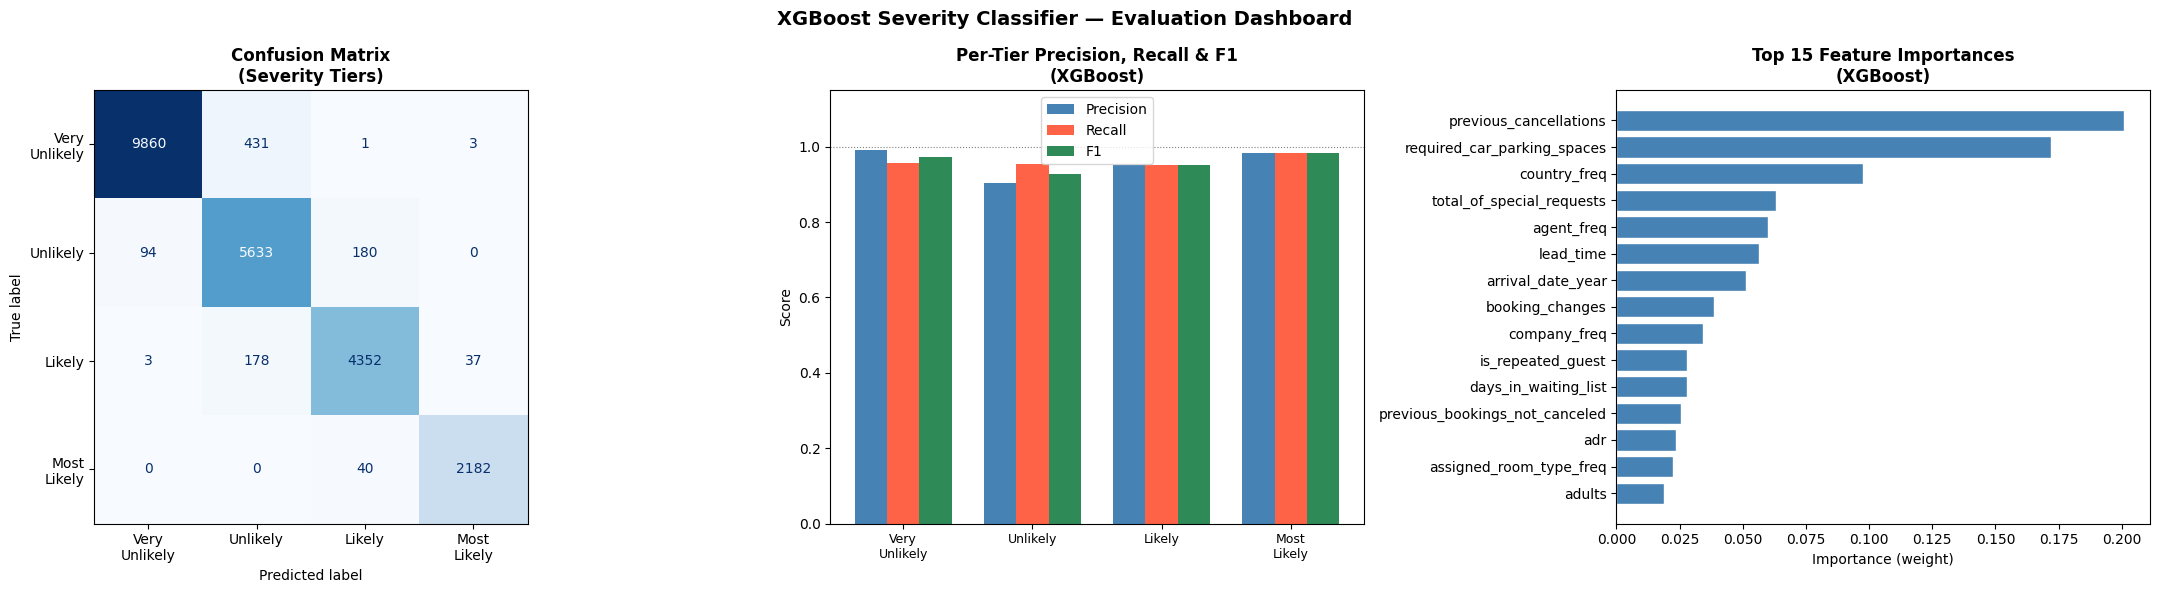

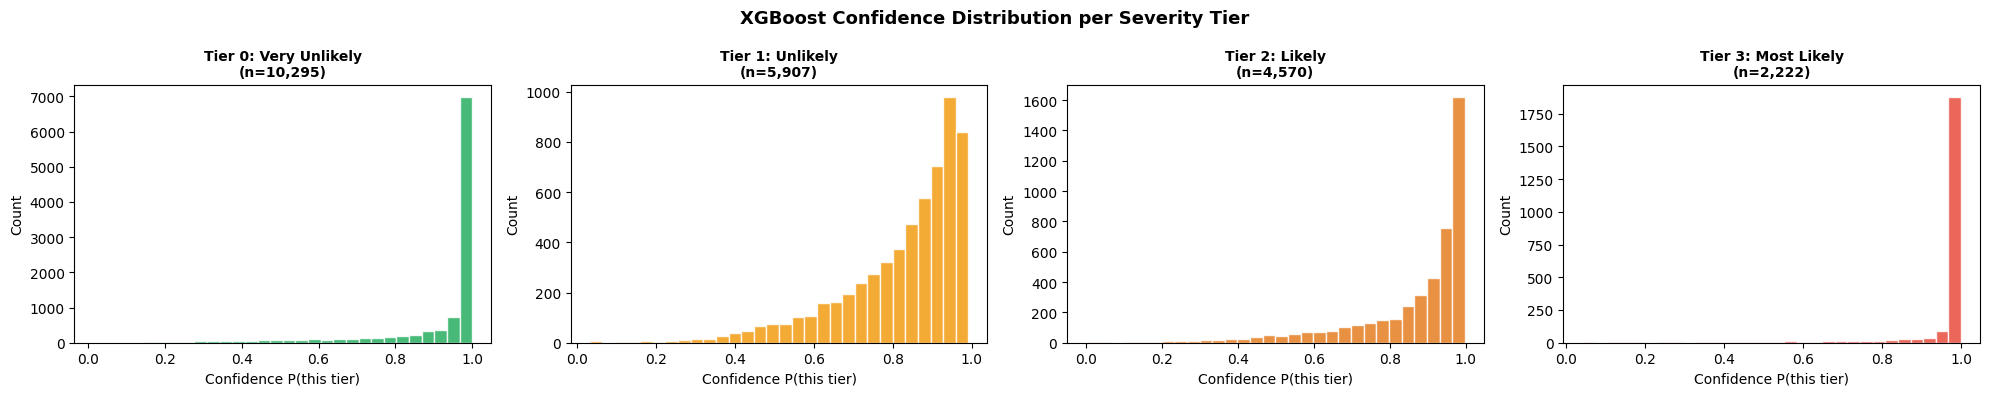

In [158]:
report_xgb = classification_report(y_test_sev, y_pred_sev, output_dict=True)

fig, axes = plt.subplots(1, 3, figsize=(22, 6))

# Confusion matrix
cm = confusion_matrix(y_test_sev, y_pred_sev)
ConfusionMatrixDisplay(
    cm, display_labels=['Very\nUnlikely', 'Unlikely', 'Likely', 'Most\nLikely']
).plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('Confusion Matrix\n(Severity Tiers)', fontweight='bold')

# Per-class precision / recall / F1
x = np.arange(4)
width = 0.25
for j, (metric, color) in enumerate(
    [('precision', 'steelblue'), ('recall', 'tomato'), ('f1-score', 'seagreen')]
):
    vals = [report_xgb[str(k)][metric] for k in range(4)]
    axes[1].bar(x + j * width, vals, width,
                label=metric.title().replace('-Score', ''), color=color)
axes[1].set_xticks(x + width)
axes[1].set_xticklabels(['Very\nUnlikely', 'Unlikely', 'Likely', 'Most\nLikely'], fontsize=9)
axes[1].set_ylim(0, 1.15)
axes[1].axhline(1.0, color='gray', linestyle=':', lw=0.8)
axes[1].set_ylabel('Score')
axes[1].set_title('Per-Tier Precision, Recall & F1\n(XGBoost)', fontweight='bold')
axes[1].legend()

# Top-15 feature importances
feat_imp = (pd.Series(xgb_model.feature_importances_, index=X.columns)
            .sort_values(ascending=False).head(15))
axes[2].barh(feat_imp.index[::-1], feat_imp.values[::-1],
             color='steelblue', edgecolor='white')
axes[2].set_xlabel('Importance (weight)')
axes[2].set_title('Top 15 Feature Importances\n(XGBoost)', fontweight='bold')

plt.suptitle('XGBoost Severity Classifier — Evaluation Dashboard',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Per-tier confidence distribution
fig, axes = plt.subplots(1, 4, figsize=(20, 4))
tier_labels_short = ['Very Unlikely', 'Unlikely', 'Likely', 'Most Likely']
for t in range(4):
    mask = y_test_sev == t
    if mask.sum() == 0:
        axes[t].set_visible(False)
        continue
    axes[t].hist(y_proba_sev[mask, t], bins=30,
                 color=SEVERITY_COLORS[t], edgecolor='white', alpha=0.85)
    axes[t].set_title(f'Tier {t}: {tier_labels_short[t]}\n(n={mask.sum():,})',
                      fontweight='bold', fontsize=10)
    axes[t].set_xlabel('Confidence P(this tier)')
    axes[t].set_ylabel('Count')
plt.suptitle('XGBoost Confidence Distribution per Severity Tier',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


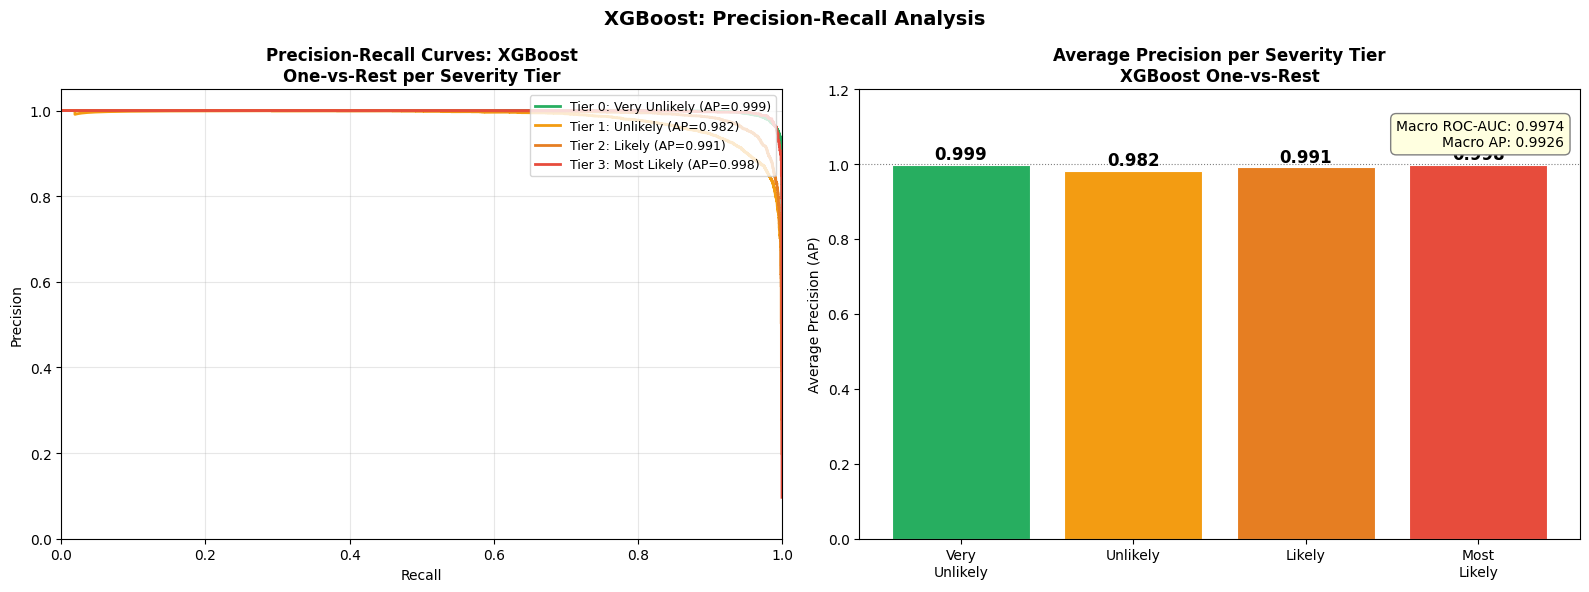

In [159]:
tier_short = ['Very Unlikely', 'Unlikely', 'Likely', 'Most Likely']
y_test_bin = np.eye(4, dtype=int)[np.asarray(y_test_sev, dtype=int)]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

ap_scores = []
for t in range(4):
    if y_test_bin[:, t].sum() == 0:
        ap_scores.append(0.0)
        continue
    prec, rec, _ = precision_recall_curve(y_test_bin[:, t], y_proba_sev[:, t])
    ap = average_precision_score(y_test_bin[:, t], y_proba_sev[:, t])
    ap_scores.append(ap)
    axes[0].plot(rec, prec, lw=2, color=SEVERITY_COLORS[t],
                 label=f'Tier {t}: {tier_short[t]} (AP={ap:.3f})')

axes[0].set_xlabel('Recall')
axes[0].set_ylabel('Precision')
axes[0].set_title('Precision-Recall Curves: XGBoost\nOne-vs-Rest per Severity Tier',
                  fontweight='bold')
axes[0].legend(fontsize=9, loc='upper right')
axes[0].grid(True, alpha=0.3)
axes[0].set_xlim(0, 1)
axes[0].set_ylim(0, 1.05)

bars = axes[1].bar(range(4), ap_scores, color=SEVERITY_COLORS,
                   edgecolor='white', linewidth=0.8)
for i, ap in enumerate(ap_scores):
    axes[1].text(i, ap + 0.015, f'{ap:.3f}', ha='center',
                 fontweight='bold', fontsize=12)
axes[1].set_xticks(range(4))
axes[1].set_xticklabels(['Very\nUnlikely', 'Unlikely', 'Likely', 'Most\nLikely'], fontsize=10)
axes[1].set_ylim(0, 1.2)
axes[1].axhline(1.0, color='gray', linestyle=':', lw=0.8)
axes[1].set_ylabel('Average Precision (AP)')
axes[1].set_title('Average Precision per Severity Tier\nXGBoost One-vs-Rest',
                  fontweight='bold')

macro_auc = roc_auc_score(y_test_sev, y_proba_sev, multi_class='ovr', average='macro')
macro_ap  = sum(ap_scores) / len(ap_scores)
axes[1].text(3.5, 1.12, f'Macro ROC-AUC: {macro_auc:.4f}\nMacro AP: {macro_ap:.4f}',
             ha='right', va='top', fontsize=10,
             bbox=dict(boxstyle='round,pad=0.4', facecolor='lightyellow', edgecolor='gray'))

plt.suptitle('XGBoost: Precision-Recall Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


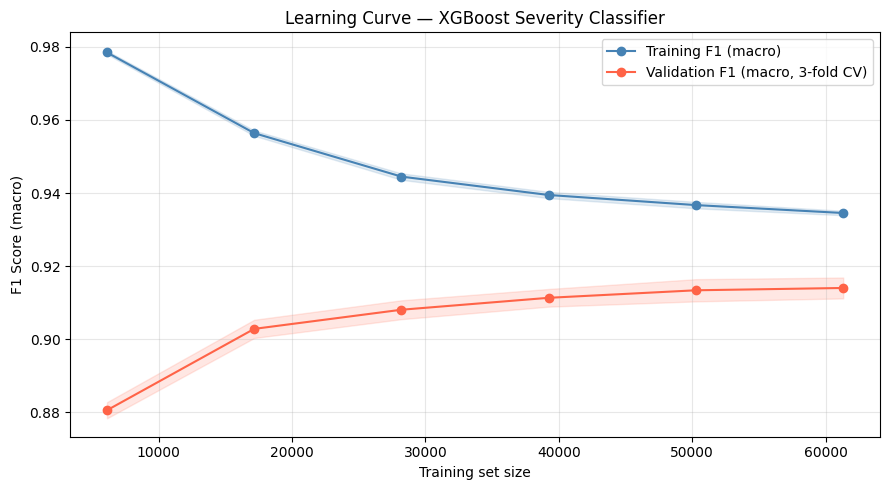

Train F1 macro (full data) : 0.9345
Val F1 macro   (3-fold CV) : 0.9140
Train / Val gap            : 0.0205
→ Curves converge — no significant overfitting detected.


In [160]:
train_sizes_xgb, train_scores_xgb, val_scores_xgb = learning_curve(
    XGBClassifier(
        objective='multi:softprob', num_class=4,
        n_estimators=100,
        max_depth=6, learning_rate=0.1,
        subsample=0.8, colsample_bytree=0.8,
        random_state=42, n_jobs=1,
        eval_metric='mlogloss', verbosity=0,
    ),
    X_train_scaled, y_train_sev,
    train_sizes=np.linspace(0.1, 1.0, 6),
    cv=3, scoring='f1_macro', n_jobs=-1,
)

tr_mean = train_scores_xgb.mean(axis=1)
tr_std  = train_scores_xgb.std(axis=1)
vl_mean = val_scores_xgb.mean(axis=1)
vl_std  = val_scores_xgb.std(axis=1)

plt.figure(figsize=(9, 5))
plt.plot(train_sizes_xgb, tr_mean, 'o-', color='steelblue',
         label='Training F1 (macro)')
plt.fill_between(train_sizes_xgb, tr_mean - tr_std, tr_mean + tr_std,
                 alpha=0.15, color='steelblue')
plt.plot(train_sizes_xgb, vl_mean, 'o-', color='tomato',
         label='Validation F1 (macro, 3-fold CV)')
plt.fill_between(train_sizes_xgb, vl_mean - vl_std, vl_mean + vl_std,
                 alpha=0.15, color='tomato')
plt.xlabel('Training set size')
plt.ylabel('F1 Score (macro)')
plt.title('Learning Curve — XGBoost Severity Classifier')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

gap = tr_mean[-1] - vl_mean[-1]
print(f'Train F1 macro (full data) : {tr_mean[-1]:.4f}')
print(f'Val F1 macro   (3-fold CV) : {vl_mean[-1]:.4f}')
print(f'Train / Val gap            : {gap:.4f}')
if gap > 0.05:
    print('→ Notable gap — consider reducing n_estimators or max_depth.')
elif vl_mean[-1] < 0.50:
    print('→ Both scores low — model may benefit from feature engineering or tuning.')
else:
    print('→ Curves converge — no significant overfitting detected.')


## 14. Results and Recommendations

### What the models do

| Model | Task | Primary Metric |
|-------|------|----------------|
| Logistic Regression | Binary cancellation prediction | Recall on cancelled class, ROC-AUC |
| XGBoost | Severity tier classification | Per-tier precision, recall, F1 |

Both models were evaluated on data neither saw during training. The learning curves confirm no significant overfitting.

---

### Operational playbook

**Run the scorer nightly.** Both models should score the current reservations ledger each morning. The output is a ranked list of bookings by severity tier for the revenue team to work through.

**Respond by tier, not uniformly:**

| Tier | Volume | Action | Cost |
|------|--------|--------|------|
| 0: Very Unlikely | Majority | None | Zero |
| 1: Unlikely | Moderate | Automated re-confirmation | Near-zero |
| 2: Likely | Smaller group | Personal call or targeted offer | Medium |
| 3: Most Likely | Small high-risk cohort | Immediate escalation with incentive budget | Higher, but recovers direct revenue |

Tier 3 is where the money is. These bookings are the most certain to cancel, and a successful retention converts a zero-revenue outcome into a full-rate night.

**Monitor performance quarterly.** Customer behaviour shifts with seasons, market conditions, and platform changes. Review recall on the cancelled class against a fresh holdout each quarter and retrain when it degrades.

**Next iteration: lead-time segmentation.** Feature importances and the correlation analysis both point to lead time as a strong cancellation signal. The next version of this model should separate last-minute bookings (under 30 days) from forward bookings (over 90 days), since the cancellation dynamics differ substantially between them.
